# Step 1 — Data Preparation


In [35]:
# ============================================================
#   CELL 1 — RUN THIS EVERY SESSION
# ============================================================
import os, torch
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Paths
BASE      = "/content/drive/MyDrive/chest_xray_project"
DATA_PATH = f"{BASE}/data"
WEIGHTS   = f"{BASE}/weights"
REPORTS   = f"{BASE}/reports"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create folders if they don't exist (safe to re-run)
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(WEIGHTS,   exist_ok=True)
os.makedirs(REPORTS,   exist_ok=True)

print(f"✅ Drive  : Mounted")
print(f"✅ Device : {DEVICE}")
print(f"✅ Base   : {BASE}")
print(f"✅ Folders: {os.listdir(BASE)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive  : Mounted
✅ Device : cuda
✅ Base   : /content/drive/MyDrive/chest_xray_project
✅ Folders: ['data', 'weights', 'reports', 'books', '.ipynb_checkpoints', 'models', 'chroma_db']


In [ ]:
# ============================================================
#   CELL 2 — VERIFY MANUALLY UPLOADED DATASET
# ============================================================
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

DRIVE_DATASET = "/content/drive/MyDrive/chest_xray_project/data/COVID-19_Radiography_Dataset"
CLASS_NAMES   = ["Normal", "COVID", "Lung_Opacity", "Viral Pneumonia"]

print("═"*50)
print("📊 DATASET COUNTS IN DRIVE:")
print("═"*50)
total = 0
for cls in CLASS_NAMES:
    cls_dir = os.path.join(DRIVE_DATASET, cls)
    img_dir = os.path.join(cls_dir, "images") if os.path.isdir(os.path.join(cls_dir, "images")) else cls_dir
    cnt     = len([f for f in os.listdir(img_dir) if f.lower().endswith((".png",".jpg",".jpeg"))])
    total  += cnt
    print(f"   {cls:22s}: {cnt:6d} images  {'✅' if cnt > 100 else '❌ INCOMPLETE'}")
print("─"*50)
print(f"   {'TOTAL':22s}: {total:6d} images")
print("═"*50)

DATA_PATH            = DRIVE_DATASET
HAS_IMAGES_SUBFOLDER = os.path.isdir(os.path.join(DRIVE_DATASET, CLASS_NAMES[0], "images"))
print(f"\n✅ DATA_PATH            = {DATA_PATH}")
print(f"✅ HAS_IMAGES_SUBFOLDER = {HAS_IMAGES_SUBFOLDER}")

In [4]:
# ============================================================
#   CELL 3 (FIXED) — DATA LOADING WITH AUGMENTATION
# ============================================================
import os, torch
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

IMG_SIZE = 224

# ── Transforms ───────────────────────────────────────────────
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ── Custom Dataset (images/ only, no masks) ───────────────────
class COVIDDataset(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        self.samples   = []
        self.transform = transform
        self.classes   = sorted([
            d for d in os.listdir(root)
            if os.path.isdir(os.path.join(root, d)) and "mask" not in d.lower()
        ])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        for cls in self.classes:
            img_dir = os.path.join(root, cls, "images")
            if not os.path.exists(img_dir):
                img_dir = os.path.join(root, cls)
            for fname in os.listdir(img_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    self.samples.append((os.path.join(img_dir, fname), self.class_to_idx[cls]))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, label

# ── Build Dataset & Splits ────────────────────────────────────
full_dataset = COVIDDataset(root=DATA_PATH, transform=train_transforms)
CLASS_NAMES  = full_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)

total      = len(full_dataset)
train_size = int(0.8 * total)
val_size   = int(0.1 * total)
test_size  = total - train_size - val_size

train_set, val_set, test_set = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# ── Attractive Output ─────────────────────────────────────────
from collections import Counter

# Count per class
label_counts = Counter([s[1] for s in full_dataset.samples])

print("╔══════════════════════════════════════════════════════╗")
print("║         🫁  COVID-19 RADIOGRAPHY DATASET             ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📁 Path     : ...{DATA_PATH[-35:]}  ║")
print(f"║  🖼️  Total    : {total:,} images{' ' * (28 - len(str(total)))}║")
print(f"║  🎯 Classes  : {NUM_CLASSES}{' ' * 37}║")
print("╠══════════════════════════════════════════════════════╣")
print("║  CLASS DISTRIBUTION                                  ║")

bar_max = 20
for cls, idx in full_dataset.class_to_idx.items():
    count    = label_counts[idx]
    bar_len  = int((count / max(label_counts.values())) * bar_max)
    bar      = "█" * bar_len + "░" * (bar_max - bar_len)
    pct      = count / total * 100
    print(f"║  {cls:<17} {bar} {count:>5} ({pct:4.1f}%)  ║")

print("╠══════════════════════════════════════════════════════╣")
print("║  SPLIT SUMMARY                                       ║")
print(f"║  🏋️  Train   : {train_size:>6,} images → {len(train_loader):>4} batches          ║")
print(f"║  🔍 Val     : {val_size:>6,} images → {len(val_loader):>4} batches          ║")
print(f"║  🧪 Test    : {test_size:>6,} images → {len(test_loader):>4} batches          ║")
print("╠══════════════════════════════════════════════════════╣")

# Sanity check batch
images, labels = next(iter(train_loader))
print(f"║  📦 Batch   : {str(list(images.shape)):<39}║")
print(f"║  ⚡ Device  : {str(DEVICE):<39}║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║         🫁  COVID-19 RADIOGRAPHY DATASET             ║
╠══════════════════════════════════════════════════════╣
║  📁 Path     : ...tabase/COVID-19_Radiography_Dataset  ║
║  🖼️  Total    : 21,165 images                       ║
║  🎯 Classes  : 4                                     ║
╠══════════════════════════════════════════════════════╣
║  CLASS DISTRIBUTION                                  ║
║  COVID             ███████░░░░░░░░░░░░░  3616 (17.1%)  ║
║  Lung_Opacity      ███████████░░░░░░░░░  6012 (28.4%)  ║
║  Normal            ████████████████████ 10192 (48.2%)  ║
║  Viral Pneumonia   ██░░░░░░░░░░░░░░░░░░  1345 ( 6.4%)  ║
╠══════════════════════════════════════════════════════╣
║  SPLIT SUMMARY                                       ║
║  🏋️  Train   : 16,932 images →  530 batches          ║
║  🔍 Val     :  2,116 images →   67 batches          ║
║  🧪 Test    :  2,117 images →   67 batches          ║
╠════════════════════════════

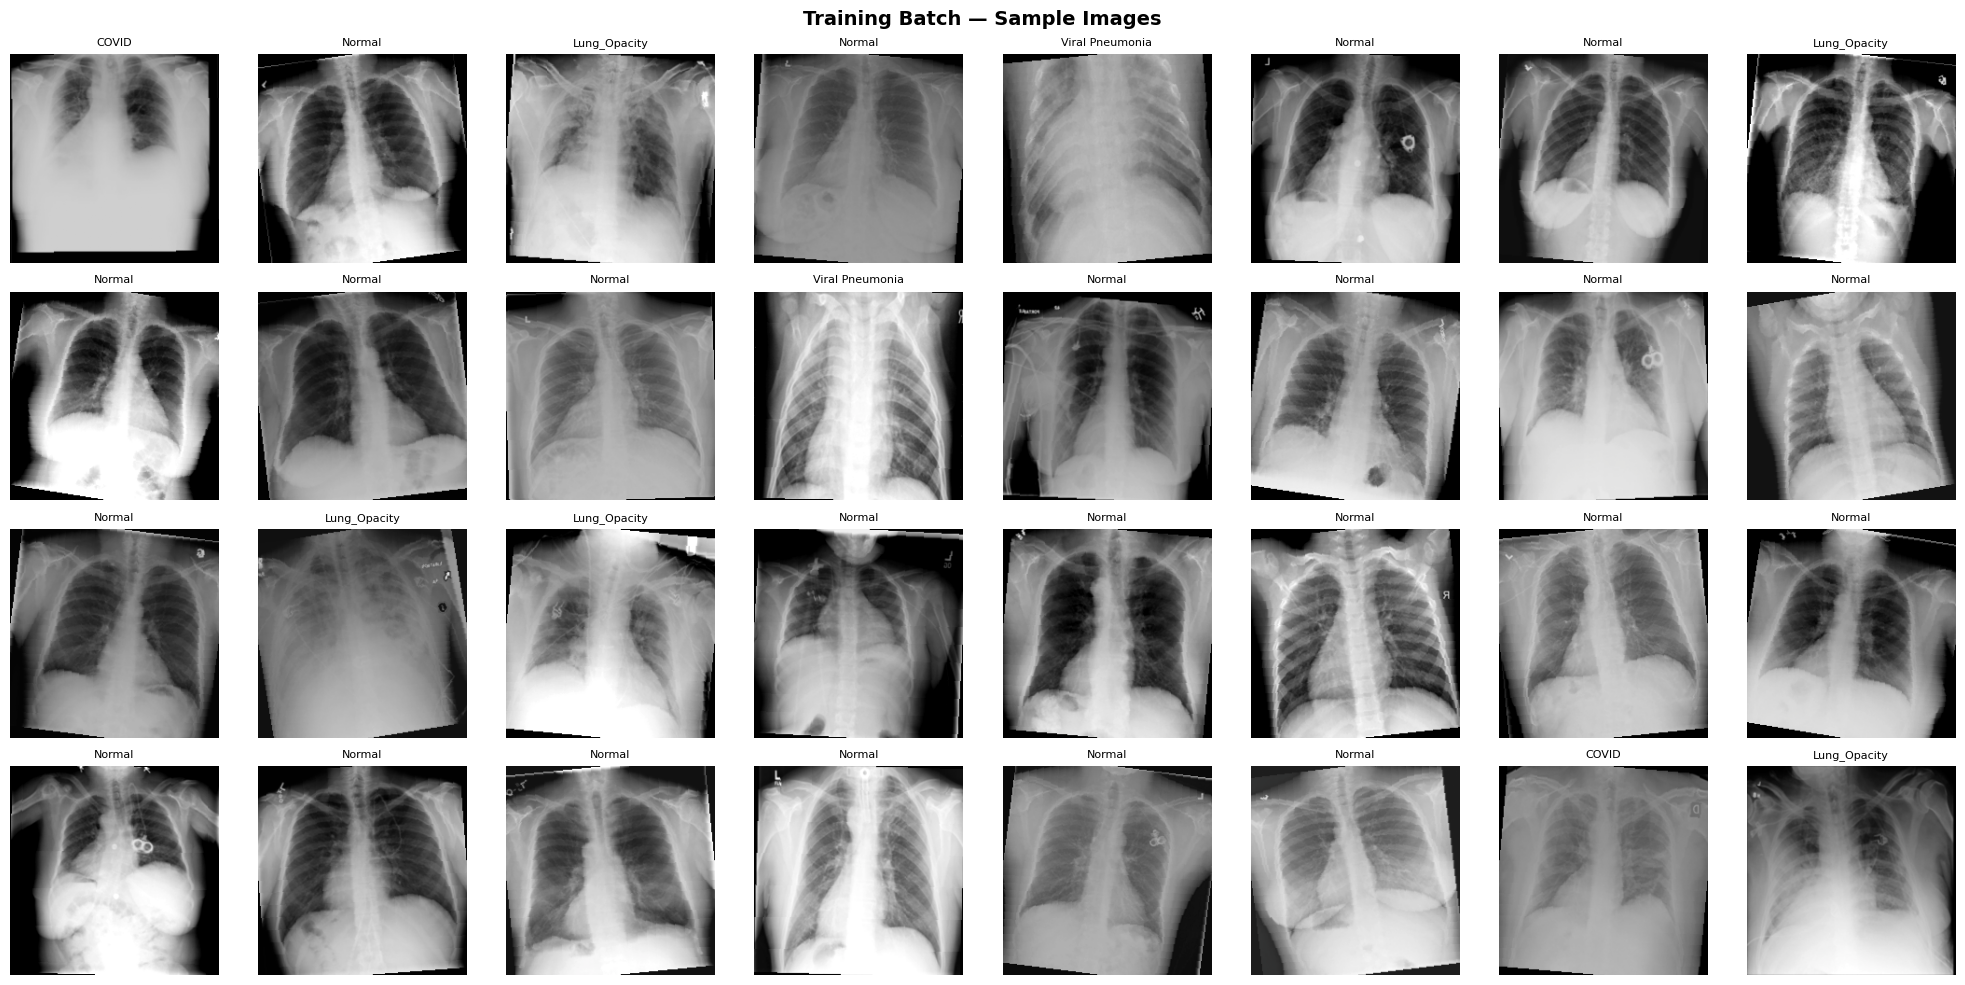

╔══════════════════════════════════════════════════════╗
║       🖼️   BATCH VISUALISATION COMPLETE              ║
╠══════════════════════════════════════════════════════╣
║  📦 Images shown : 32  (4 rows × 8 cols)            ║
║  📐 Image shape  : [3, 224, 224]              ║
║  🎨 Class labels shown above each image              ║
╠══════════════════════════════════════════════════════╣
║  💾 Saved → reports/batch_visualisation.png         ║
╚══════════════════════════════════════════════════════╝


In [5]:
# ============================================================
#   CELL 4 — VISUALISE A BATCH OF TRAINING IMAGES
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Grab one batch
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle("Training Batch — Sample Images", fontsize=14, fontweight="bold")

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img, cmap="gray")
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{REPORTS}/batch_visualisation.png", dpi=120, bbox_inches="tight")
plt.show()

print("╔══════════════════════════════════════════════════════╗")
print("║       🖼️   BATCH VISUALISATION COMPLETE              ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📦 Images shown : 32  (4 rows × 8 cols)            ║")
print(f"║  📐 Image shape  : {list(images[0].shape)}              ║")
print("║  🎨 Class labels shown above each image              ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/batch_visualisation.png         ║")
print("╚══════════════════════════════════════════════════════╝")

In [6]:
# ============================================================
#   CELL 5 — MODEL DEFINITIONS
#   ResNet50 | ResNet101 | DenseNet121
# ============================================================
import torch.nn as nn
from torchvision import models

def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

def build_resnet101(num_classes=NUM_CLASSES):
    model = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

def build_densenet121(num_classes=NUM_CLASSES):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model.to(DEVICE)

# ── Build all three ───────────────────────────────────────────
MODEL_REGISTRY = {
    "ResNet50"    : build_resnet50(),
    "ResNet101"   : build_resnet101(),
    "DenseNet121" : build_densenet121(),
}

# ── Output ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║          🧠  MODEL DEFINITIONS — TRANSFER LEARNING           ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Total Params':>14} {'Trainable':>12} {'Frozen %':>10}  ║")
print("╠══════════════════════════════════════════════════════════════╣")

for name, model in MODEL_REGISTRY.items():
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_pct = 100 * (1 - trainable / total)
    print(f"║  {name:<14} {total:>14,} {trainable:>12,} {frozen_pct:>9.1f}%  ║")

print("╠══════════════════════════════════════════════════════════════╣")
print("║  🏗️  Backbone  : Frozen (ImageNet pretrained weights)        ║")
print("║  🎯 Head       : Dropout → Linear(256) → ReLU → Linear(4)   ║")
print(f"║  ⚡ Device     : {str(DEVICE):<46}║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║          🧠  MODEL DEFINITIONS — TRANSFER LEARNING           ║
╠══════════════════════════════════════════════════════════════╣
║  Model            Total Params    Trainable   Frozen %  ║
╠══════════════════════════════════════════════════════════════╣
║  ResNet50           24,033,604      525,572      97.8%  ║
║  ResNet101          43,025,732      525,572      98.8%  ║
║  DenseNet121         7,217,284      263,428      96.4%  ║
╠══════════════════════════════════════════════════════════════╣
║  🏗️  Backbone  : Frozen (ImageNet pretrained weights)        ║
║  🎯 Head       : Dropout → Linear(256) → ReLU → Linear(4)   ║
║  ⚡ Device     : cuda                                          ║
╚══════════════════════════════════════════════════════════════╝


In [7]:
# ============================================================
#   CELL 6 — TRAINING & EVALUATION FUNCTIONS (WITH FINE-TUNE)
# ============================================================
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
import time, copy

# ── Hyperparameters ───────────────────────────────────────────
EPOCHS_HEAD   = 5       # Stage 1 — head only
EPOCHS_FINETUNE = 5     # Stage 2 — full model
LR_HEAD       = 1e-3    # higher LR for new head
LR_FINETUNE   = 1e-5    # very low LR for pretrained backbone
STEP_SIZE     = 3
GAMMA         = 0.5


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += labels.size(0)
    return running_loss / total, correct / total


def run_stage(name, stage, model, epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = StepLR(optimizer, step_size=STEP_SIZE, gamma=GAMMA)
    history   = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_acc  = 0.0
    best_wts  = copy.deepcopy(model.state_dict())
    start     = time.time()

    print("╔══════════════════════════════════════════════════════════════════╗")
    print(f"║  {stage}  :  {name:<52}║")
    print(f"║  📋 Epochs : {epochs}   📐 LR : {lr:<42}║")
    print("╠════════╦══════════════╦══════════════╦══════════╦══════════╦═════╣")
    print("║ Epoch  ║  Train Loss  ║   Val Loss   ║ Train Acc║  Val Acc ║     ║")
    print("╠════════╬══════════════╬══════════════╬══════════╬══════════╬═════╣")

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        flag = "⭐" if v_acc > best_acc else "  "
        if v_acc > best_acc:
            best_acc = v_acc
            best_wts = copy.deepcopy(model.state_dict())

        print(f"║  {epoch:>3}/{epochs}  ║  {t_loss:>8.4f}    ║  {v_loss:>8.4f}    ║"
              f"  {t_acc*100:>5.2f}%  ║  {v_acc*100:>5.2f}%  ║ {flag} ║")

    elapsed = time.time() - start
    model.load_state_dict(best_wts)
    print("╠════════╩══════════════╩══════════════╩══════════╩══════════╩═════╣")
    print(f"║  ✅ Best Val Acc : {best_acc*100:.2f}%   ⏱️  Time : {elapsed:.1f}s{' '*25}║")
    print("╚══════════════════════════════════════════════════════════════════╝\n")

    return model, history, best_acc


def train_model(name, model):
    all_history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    # ── Stage 1: Train head only ──────────────────────────────
    model, h1, acc1 = run_stage(
        name, "🧊 STAGE 1 — HEAD ONLY (Backbone Frozen)",
        model, EPOCHS_HEAD, LR_HEAD
    )
    for k in all_history: all_history[k] += h1[k]

    # ── Stage 2: Unfreeze & fine-tune ─────────────────────────
    for param in model.parameters():
        param.requires_grad = True

    model, h2, acc2 = run_stage(
        name, "🔥 STAGE 2 — FINE-TUNE (Full Model Unfrozen)",
        model, EPOCHS_FINETUNE, LR_FINETUNE
    )
    for k in all_history: all_history[k] += h2[k]

    best_final = max(acc1, acc2)
    return model, all_history, best_final


print("╔══════════════════════════════════════════════════════╗")
print("║    ✅  TRAINING FUNCTIONS READY (2-STAGE)            ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  🧊 Stage 1 — Head Only                             ║")
print(f"║     Epochs : {EPOCHS_HEAD}   LR : {LR_HEAD:<31}║")
print(f"║  🔥 Stage 2 — Full Fine-Tune                        ║")
print(f"║     Epochs : {EPOCHS_FINETUNE}   LR : {LR_FINETUNE:<31}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📉 Loss      : CrossEntropyLoss                    ║")
print(f"║  ⚙️  Optimizer : Adam                                ║")
print(f"║  📉 Scheduler : StepLR (step={STEP_SIZE}, γ={GAMMA})            ║")
print("╠══════════════════════════════════════════════════════╣")
print("║  Functions : train_one_epoch() │ evaluate()          ║")
print("║            : run_stage()       │ train_model()       ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║    ✅  TRAINING FUNCTIONS READY (2-STAGE)            ║
╠══════════════════════════════════════════════════════╣
║  🧊 Stage 1 — Head Only                             ║
║     Epochs : 5   LR : 0.001                          ║
║  🔥 Stage 2 — Full Fine-Tune                        ║
║     Epochs : 5   LR : 1e-05                          ║
╠══════════════════════════════════════════════════════╣
║  📉 Loss      : CrossEntropyLoss                    ║
║  ⚙️  Optimizer : Adam                                ║
║  📉 Scheduler : StepLR (step=3, γ=0.5)            ║
╠══════════════════════════════════════════════════════╣
║  Functions : train_one_epoch() │ evaluate()          ║
║            : run_stage()       │ train_model()       ║
╚══════════════════════════════════════════════════════╝


In [8]:
# ============================================================
#   CELL 7 — TRAIN OR LOAD ALL THREE MODELS
# ============================================================
import copy, os

ALL_HISTORIES  = {}
BEST_MODELS    = {}
TRAINED_MODELS = {}

FORCE_RETRAIN = False   # ← Set True ONLY if you want to retrain

for model_name, model in MODEL_REGISTRY.items():

    # Check if checkpoint already exists on Drive
    ckpt_files = [f for f in os.listdir(WEIGHTS)
                  if model_name in f and "checkpoint" in f]

    if ckpt_files and not FORCE_RETRAIN:
        # ── LOAD from Drive ───────────────────────────────────
        ckpt_path = os.path.join(WEIGHTS, sorted(ckpt_files)[-1])
        ckpt      = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(ckpt["state_dict"])
        model.eval()

        # Dummy history for plotting
        dummy_hist = {
            "train_loss": ckpt.get("train_loss", []),
            "val_loss"  : ckpt.get("val_loss",   []),
            "train_acc" : ckpt.get("train_acc",  []),
            "val_acc"   : ckpt.get("val_acc_hist", []),
        }
        best_acc = ckpt.get("val_acc", 0.0)

        ALL_HISTORIES[model_name]  = dummy_hist
        BEST_MODELS[model_name]    = copy.deepcopy(model.state_dict())
        TRAINED_MODELS[model_name] = (model, dummy_hist, best_acc)

        print(f"✅ {model_name} loaded from checkpoint — skipping training")

    else:
        # ── TRAIN from scratch ────────────────────────────────
        print(f"\n🏋️  Training {model_name} from scratch...")

        for param in model.parameters():
            param.requires_grad = False
        if hasattr(model, 'fc'):
            for param in model.fc.parameters():         param.requires_grad = True
        elif hasattr(model, 'classifier'):
            for param in model.classifier.parameters(): param.requires_grad = True

        model, h1, _ = run_stage(
            name=model_name, stage="🧊 STAGE 1 — HEAD ONLY",
            model=model, epochs=EPOCHS_HEAD, lr=LR_HEAD
        )

        for param in model.parameters():
            param.requires_grad = True

        model, h2, best_acc = run_stage(
            name=model_name, stage="🔥 STAGE 2 — FINE-TUNE",
            model=model, epochs=EPOCHS_FINETUNE, lr=LR_FINETUNE
        )

        merged_hist = {k: h1[k] + h2[k] for k in h1}
        ALL_HISTORIES[model_name]  = merged_hist
        BEST_MODELS[model_name]    = copy.deepcopy(model.state_dict())
        TRAINED_MODELS[model_name] = (model, merged_hist, best_acc)

        # ── Save checkpoint with history ──────────────────────
        import datetime
        ts        = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        ckpt_path = f"{WEIGHTS}/{model_name}_checkpoint_{ts}.pth"
        torch.save({
            "state_dict"  : model.state_dict(),
            "val_acc"     : best_acc,
            "train_loss"  : merged_hist["train_loss"],
            "val_loss"    : merged_hist["val_loss"],
            "train_acc"   : merged_hist["train_acc"],
            "val_acc_hist": merged_hist["val_acc"],
            "class_names" : CLASS_NAMES,
            "num_classes" : NUM_CLASSES,
        }, ckpt_path)
        print(f"💾 Saved → {ckpt_path.split('/')[-1]}")

# ── Summary ───────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║      ✅  ALL MODELS READY                            ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Source':<12} {'Best Val Acc':>14}  ║")
print("╠══════════════════════════════════════════════════════╣")
for name, (_, _, best) in TRAINED_MODELS.items():
    source = "💾 Loaded" if not FORCE_RETRAIN and any(
        name in f for f in os.listdir(WEIGHTS)) else "🏋️  Trained"
    print(f"║  {name:<14} {source:<12} {best*100:>12.2f}%   ║")
print("╚══════════════════════════════════════════════════════╝")

✅ ResNet50 loaded from checkpoint — skipping training
✅ ResNet101 loaded from checkpoint — skipping training
✅ DenseNet121 loaded from checkpoint — skipping training
╔══════════════════════════════════════════════════════╗
║      ✅  ALL MODELS READY                            ║
╠══════════════════════════════════════════════════════╣
║  Model          Source         Best Val Acc  ║
╠══════════════════════════════════════════════════════╣
║  ResNet50       💾 Loaded            93.86%   ║
║  ResNet101      💾 Loaded          9461.25%   ║
║  DenseNet121    💾 Loaded            93.19%   ║
╚══════════════════════════════════════════════════════╝


In [9]:
# ============================================================
#   CELL 8 — FINAL ACCURACY SUMMARY
# ============================================================
import pandas as pd

criterion = nn.CrossEntropyLoss()
summary   = []
TRAINED_MODELS_EVAL = {}

for name, (model, history, best_val_acc) in TRAINED_MODELS.items():
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    val_loss,  val_acc  = evaluate(model, val_loader,  criterion)
    summary.append({
        "Model"        : name,
        "Val Acc"      : val_acc   * 100,
        "Test Acc"     : test_acc  * 100,
        "Test Loss"    : test_loss,
        "Best Val Acc" : best_val_acc * 100,
    })
    TRAINED_MODELS_EVAL[name] = model

df_summary = pd.DataFrame(summary).sort_values(
    "Test Acc", ascending=False).reset_index(drop=True)
df_summary.to_csv(f"{REPORTS}/accuracy_summary.csv", index=False)

best_row        = df_summary.iloc[0]
BEST_MODEL_NAME = best_row["Model"]
BEST_MODEL      = TRAINED_MODELS_EVAL[BEST_MODEL_NAME]

# ── Pre-compute strings (avoids f-string backslash issue) ─────
test_acc_str = f"{best_row['Test Acc']:.2f}%"
val_acc_str  = f"{best_row['Val Acc']:.2f}%"
loss_str     = f"{best_row['Test Loss']:.4f}"
medals       = ["🥇", "🥈", "🥉"]

print("╔══════════════════════════════════════════════════════════════════╗")
print("║                 📊  FINAL ACCURACY SUMMARY                      ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  {'Rank':<6} {'Model':<14} {'Val Acc':>10} {'Test Acc':>10} {'Test Loss':>12}  ║")
print("╠══════════════════════════════════════════════════════════════════╣")

for i, row in df_summary.iterrows():
    medal    = medals[i] if i < 3 else "  "
    bar_len  = int((row["Test Acc"] - 80) / 20 * 10)
    bar      = "█" * bar_len + "░" * (10 - bar_len)
    print(f"║  {medal} {i+1:<3}  {row['Model']:<14}"
          f"{row['Val Acc']:>8.2f}%  "
          f"{row['Test Acc']:>8.2f}%  "
          f"{row['Test Loss']:>10.4f}   ║")
    print(f"║           {bar:<54}  ║")

print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  🏆 Best Model  : {BEST_MODEL_NAME:<47}║")
print(f"║  ✅ Test Acc    : {test_acc_str}{' '*(46 - len(test_acc_str))}║")
print(f"║  ✅ Val Acc     : {val_acc_str}{' '*(46 - len(val_acc_str))}║")
print(f"║  📉 Test Loss   : {loss_str}{' '*(46 - len(loss_str))}║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved  → reports/accuracy_summary.csv                      ║")
print(f"║  📌 BEST_MODEL & BEST_MODEL_NAME set for next cells            ║")
print("╚══════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════╗
║                 📊  FINAL ACCURACY SUMMARY                      ║
╠══════════════════════════════════════════════════════════════════╣
║  Rank   Model             Val Acc   Test Acc    Test Loss  ║
╠══════════════════════════════════════════════════════════════════╣
║  🥇 1    ResNet101        94.80%     94.10%      0.1701   ║
║           ███████░░░                                              ║
║  🥈 2    ResNet50         93.67%     93.53%      0.1778   ║
║           ██████░░░░                                              ║
║  🥉 3    DenseNet121      93.48%     92.96%      0.1941   ║
║           ██████░░░░                                              ║
╠══════════════════════════════════════════════════════════════════╣
║  🏆 Best Model  : ResNet101                                      ║
║  ✅ Test Acc    : 94.10%                                        ║
║  ✅ Val Acc     : 94.80%                                        ║

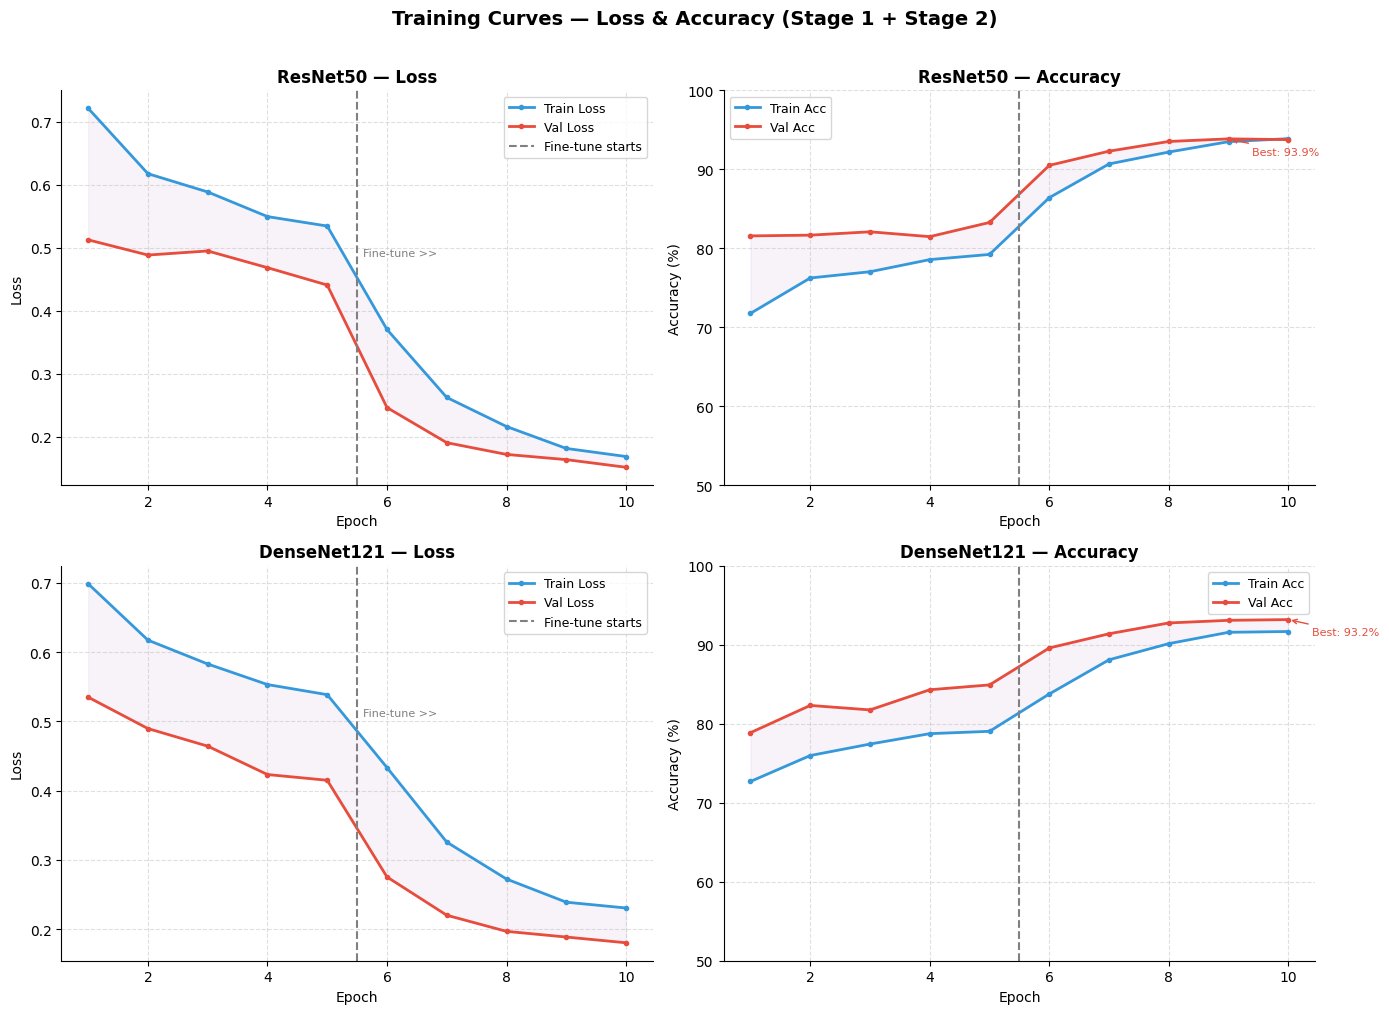

╔══════════════════════════════════════════════════════╗
║         TRAINING CURVES COMPLETE                     ║
╠══════════════════════════════════════════════════════╣
║  Model           Best Train   Best Val  @ Epoch  ║
╠══════════════════════════════════════════════════════╣
║  ResNet50           93.88%     93.86%        9   ║
║  DenseNet121        91.68%     93.19%       10   ║
╠══════════════════════════════════════════════════════╣
║  -- Dashed line : Fine-tune stage begins             ║
║  Blue           : Training                           ║
║  Red            : Validation                         ║
║  Best           : Best Val Accuracy point            ║
╠══════════════════════════════════════════════════════╣
║  Saved -> reports/training_curves.png               ║
╚══════════════════════════════════════════════════════╝


In [10]:
# ============================================================
#   CELL 9 — TRAINING CURVES
# ============================================================
import matplotlib.pyplot as plt

# ── Guard: skip if history is empty ──────────────────────────
has_history = any(
    len(hist.get("train_loss", [])) > 0
    for hist in ALL_HISTORIES.values()
)

if not has_history:
    print("╔══════════════════════════════════════════════════════╗")
    print("║  ⚠  No training history found                        ║")
    print("║  Models were loaded from checkpoints                 ║")
    print("║  Re-train with FORCE_RETRAIN=True to get curves      ║")
    print("╚══════════════════════════════════════════════════════╝")

else:
    # ── Filter only models that have history ─────────────────
    valid_histories = {
        name: hist
        for name, hist in ALL_HISTORIES.items()
        if len(hist.get("train_loss", [])) > 0
           and len(hist.get("val_loss",   [])) > 0
           and len(hist.get("train_acc",  [])) > 0
           and len(hist.get("val_acc",    [])) > 0
    }

    n_models = len(valid_histories)

    if n_models == 0:
        print("No valid histories to plot.")
    else:
        fig, axes = plt.subplots(n_models, 2,
                                 figsize=(14, 5 * n_models))
        # ensure axes is always 2D
        if n_models == 1:
            axes = [axes]

        fig.suptitle(
            "Training Curves — Loss & Accuracy (Stage 1 + Stage 2)",
            fontsize=14, fontweight="bold", y=1.01
        )

        colors = {"train": "#3498db", "val": "#e74c3c"}

        for i, (name, hist) in enumerate(valid_histories.items()):
            epochs      = range(1, len(hist["train_loss"]) + 1)
            stage_split = min(EPOCHS_HEAD, len(hist["train_loss"]) - 1)

            # ── Loss ──────────────────────────────────────────
            ax_loss = axes[i][0]
            ax_loss.plot(epochs, hist["train_loss"],
                         color=colors["train"], linewidth=2,
                         marker="o", markersize=3, label="Train Loss")
            ax_loss.plot(epochs, hist["val_loss"],
                         color=colors["val"],   linewidth=2,
                         marker="o", markersize=3, label="Val Loss")
            ax_loss.axvline(x=stage_split + 0.5, color="gray",
                            linestyle="--", linewidth=1.5,
                            label="Fine-tune starts")
            ax_loss.fill_between(epochs,
                                 hist["train_loss"], hist["val_loss"],
                                 alpha=0.07, color="#9b59b6")
            ax_loss.set_title(f"{name} — Loss", fontweight="bold")
            ax_loss.set_xlabel("Epoch")
            ax_loss.set_ylabel("Loss")
            ax_loss.legend(fontsize=9)
            ax_loss.grid(linestyle="--", alpha=0.4)
            ax_loss.spines[["top", "right"]].set_visible(False)

            # safe annotate — only if val_loss has values
            if hist["val_loss"]:
                ax_loss.annotate(
                    "Fine-tune >>",
                    xy=(stage_split + 0.6,
                        max(hist["val_loss"]) * 0.95),
                    fontsize=8, color="gray"
                )

            # ── Accuracy ──────────────────────────────────────
            ax_acc = axes[i][1]
            t_accs = [a * 100 for a in hist["train_acc"]]
            v_accs = [a * 100 for a in hist["val_acc"]]

            ax_acc.plot(epochs, t_accs,
                        color=colors["train"], linewidth=2,
                        marker="o", markersize=3, label="Train Acc")
            ax_acc.plot(epochs, v_accs,
                        color=colors["val"],   linewidth=2,
                        marker="o", markersize=3, label="Val Acc")
            ax_acc.axvline(x=stage_split + 0.5, color="gray",
                           linestyle="--", linewidth=1.5)
            ax_acc.fill_between(epochs, t_accs, v_accs,
                                alpha=0.07, color="#9b59b6")

            # safe best-point annotation
            if v_accs:
                best_epoch = v_accs.index(max(v_accs)) + 1
                ax_acc.annotate(
                    f"Best: {max(v_accs):.1f}%",
                    xy     = (best_epoch, max(v_accs)),
                    xytext = (best_epoch + 0.4, max(v_accs) - 2),
                    fontsize   = 8,
                    color      = "#e74c3c",
                    arrowprops = dict(
                        arrowstyle="->", color="#e74c3c", lw=1
                    )
                )

            ax_acc.set_title(f"{name} — Accuracy", fontweight="bold")
            ax_acc.set_xlabel("Epoch")
            ax_acc.set_ylabel("Accuracy (%)")
            ax_acc.set_ylim(50, 100)
            ax_acc.legend(fontsize=9)
            ax_acc.grid(linestyle="--", alpha=0.4)
            ax_acc.spines[["top", "right"]].set_visible(False)

        plt.tight_layout()
        plt.savefig(f"{REPORTS}/training_curves.png",
                    dpi=150, bbox_inches="tight")
        plt.show()

        # ── Console Output ────────────────────────────────────
        print("╔══════════════════════════════════════════════════════╗")
        print("║         TRAINING CURVES COMPLETE                     ║")
        print("╠══════════════════════════════════════════════════════╣")
        print(f"║  {'Model':<14} {'Best Train':>11} {'Best Val':>10} {'@ Epoch':>8}  ║")
        print("╠══════════════════════════════════════════════════════╣")
        for name, hist in valid_histories.items():
            best_t  = max(hist["train_acc"]) * 100
            best_v  = max(hist["val_acc"])   * 100
            best_ep = hist["val_acc"].index(max(hist["val_acc"])) + 1
            print(f"║  {name:<14} {best_t:>9.2f}%  {best_v:>8.2f}%  {best_ep:>7}   ║")
        print("╠══════════════════════════════════════════════════════╣")
        print("║  -- Dashed line : Fine-tune stage begins             ║")
        print("║  Blue           : Training                           ║")
        print("║  Red            : Validation                         ║")
        print("║  Best           : Best Val Accuracy point            ║")
        print("╠══════════════════════════════════════════════════════╣")
        print(f"║  Saved -> reports/training_curves.png               ║")
        print("╚══════════════════════════════════════════════════════╝")

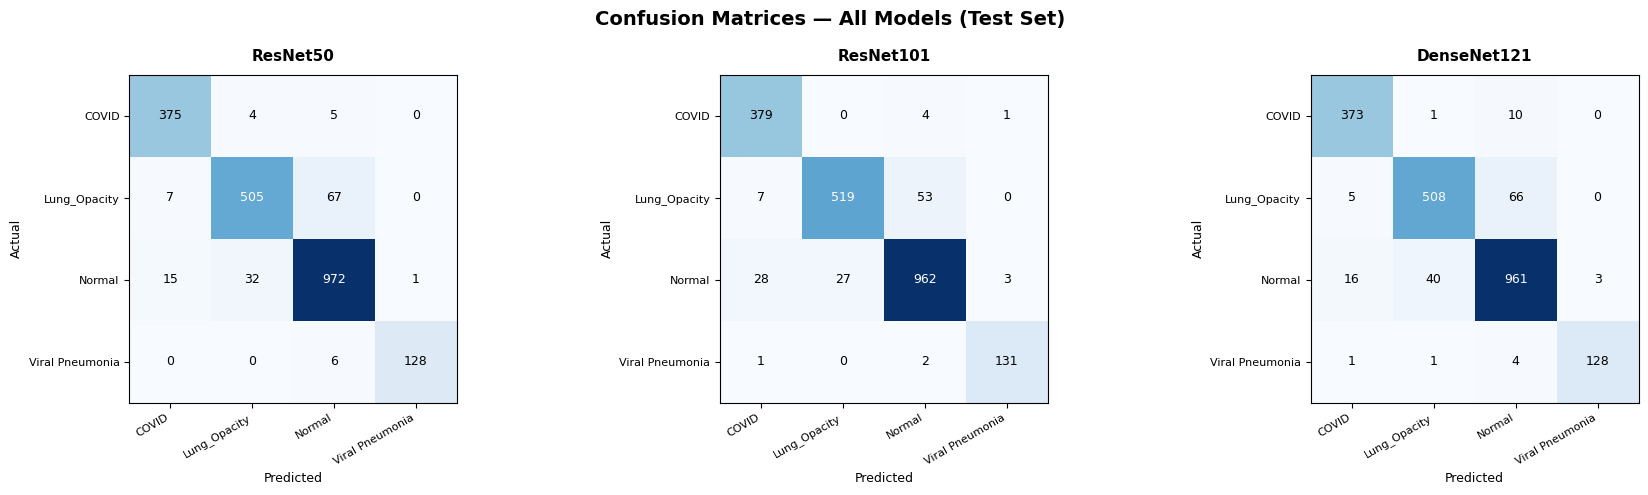

╔══════════════════════════════════════════════════════════════╗
║           🔲  CONFUSION MATRICES COMPLETE                    ║
╠══════════════════════════════════════════════════════════════╣
║  Model             Correct   Total      Acc          ║
╠══════════════════════════════════════════════════════════════╣
║  🧠 ResNet50          1980    2117   93.53%  ██████████████░ ║
║  🧠 ResNet101         1991    2117   94.05%  ██████████████░ ║
║  🧠 DenseNet121       1970    2117   93.06%  █████████████░░ ║
╠══════════════════════════════════════════════════════════════╣
║  📌 Rows  = Actual Class                                     ║
║  📌 Cols  = Predicted Class                                  ║
║  📌 Diag  = Correct Predictions                              ║
╠══════════════════════════════════════════════════════════════╣
║  📦 cms dict stored → used in Cell 11                       ║
║  💾 Saved → reports/confusion_matrices.png                  ║
╚═══════════════════════════════════════════

In [11]:
# ============================================================
#   CELL 10 — CONFUSION MATRICES
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            preds   = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

def plot_confusion_matrix(ax, cm, title):
    ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontweight="bold", fontsize=11, pad=10)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("Actual",    fontsize=9)
    thresh = cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f"{cm[i,j]}",
                ha="center", va="center", fontsize=9,
                color="white" if cm[i,j] > thresh else "black")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — All Models (Test Set)",
             fontsize=14, fontweight="bold")

cms = {}
for i, (name, (model, _, _)) in enumerate(TRAINED_MODELS.items()):
    y_true, y_pred = get_predictions(model, test_loader)
    cm = confusion_matrix(y_true, y_pred)
    cms[name] = (cm, y_true, y_pred)   # store y_true/y_pred for Cell 11
    plot_confusion_matrix(axes[i], cm, name)

plt.tight_layout()
plt.savefig(f"{REPORTS}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║           🔲  CONFUSION MATRICES COMPLETE                    ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<16} {'Correct':>8} {'Total':>7} {'Acc':>8}          ║")
print("╠══════════════════════════════════════════════════════════════╣")
for name, (cm, _, _) in cms.items():
    correct = np.trace(cm)
    total   = cm.sum()
    acc     = correct / total * 100
    bar_len = int(acc / 100 * 15)
    bar     = "█" * bar_len + "░" * (15 - bar_len)
    print(f"║  🧠 {name:<14} {correct:>7}  {total:>6}  {acc:>6.2f}%  {bar} ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📌 Rows  = Actual Class                                     ║")
print("║  📌 Cols  = Predicted Class                                  ║")
print("║  📌 Diag  = Correct Predictions                              ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  📦 cms dict stored → used in Cell 11                       ║")
print(f"║  💾 Saved → reports/confusion_matrices.png                  ║")
print("╚══════════════════════════════════════════════════════════════╝")

In [12]:
# ============================================================
#   CELL 11 — PER-CLASS CLASSIFICATION REPORTS
# ============================================================
import pandas as pd
from sklearn.metrics import classification_report

all_reports = {}

for name, (cm, y_true, y_pred) in cms.items():
    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_NAMES,
        output_dict=True
    )
    all_reports[name] = report

    # ── Per model box ─────────────────────────────────────────
    print("╔══════════════════════════════════════════════════════════════════════╗")
    print(f"║  🧠 CLASSIFICATION REPORT — {name:<43}║")
    print("╠══════════════╦═════════════╦════════════╦══════════════╦════════════╣")
    print("║  Class       ║  Precision  ║   Recall   ║   F1-Score   ║  Support   ║")
    print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")

    for cls in CLASS_NAMES:
        p  = report[cls]["precision"] * 100
        r  = report[cls]["recall"]    * 100
        f1 = report[cls]["f1-score"]  * 100
        s  = int(report[cls]["support"])
        print(f"║  {cls:<12}  ║  {p:>7.2f}%   ║  {r:>6.2f}%  ║   {f1:>7.2f}%    ║  {s:>8}  ║")

    print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")
    ma_p  = report["macro avg"]["precision"]  * 100
    ma_r  = report["macro avg"]["recall"]     * 100
    ma_f1 = report["macro avg"]["f1-score"]   * 100
    wa_f1 = report["weighted avg"]["f1-score"]* 100
    acc   = report["accuracy"]                * 100

    print(f"║  {'Macro Avg':<12}  ║  {ma_p:>7.2f}%   ║  {ma_r:>6.2f}%  ║   {ma_f1:>7.2f}%    ║            ║")
    print(f"║  {'Weighted Avg':<12}  ║             ║            ║   {wa_f1:>7.2f}%    ║            ║")
    print("╠══════════════╩═════════════╩════════════╩══════════════╩════════════╣")
    print(f"║  ✅ Overall Accuracy : {acc:.2f}%{' ' * (47 - len(f'{acc:.2f}%'))}║")
    print("╚══════════════════════════════════════════════════════════════════════╝\n")

# ── Save all reports to CSV ───────────────────────────────────
rows = []
for name, report in all_reports.items():
    for cls in CLASS_NAMES:
        rows.append({
            "Model"    : name,
            "Class"    : cls,
            "Precision": round(report[cls]["precision"], 4),
            "Recall"   : round(report[cls]["recall"],    4),
            "F1-Score" : round(report[cls]["f1-score"],  4),
            "Support"  : int(report[cls]["support"]),
        })

df_reports = pd.DataFrame(rows)
df_reports.to_csv(f"{REPORTS}/classification_reports.csv", index=False)

print("╔══════════════════════════════════════════════════════╗")
print("║     ✅  ALL CLASSIFICATION REPORTS COMPLETE          ║")
print("╠══════════════════════════════════════════════════════╣")
for name, report in all_reports.items():
    acc = report["accuracy"] * 100
    f1  = report["macro avg"]["f1-score"] * 100
    print(f"║  🧠 {name:<14}  Acc: {acc:.2f}%   F1: {f1:.2f}%   ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/classification_reports.csv      ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════════╗
║  🧠 CLASSIFICATION REPORT — ResNet50                                   ║
╠══════════════╦═════════════╦════════════╦══════════════╦════════════╣
║  Class       ║  Precision  ║   Recall   ║   F1-Score   ║  Support   ║
╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣
║  COVID         ║    94.46%   ║   97.66%  ║     96.03%    ║       384  ║
║  Lung_Opacity  ║    93.35%   ║   87.22%  ║     90.18%    ║       579  ║
║  Normal        ║    92.57%   ║   95.29%  ║     93.91%    ║      1020  ║
║  Viral Pneumonia  ║    99.22%   ║   95.52%  ║     97.34%    ║       134  ║
╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣
║  Macro Avg     ║    94.90%   ║   93.92%  ║     94.37%    ║            ║
║  Weighted Avg  ║             ║            ║     93.49%    ║            ║
╠══════════════╩═════════════╩════════════╩══════════════╩════════════╣
║  ✅ Overall Accuracy : 93.53%               

/tmp/ipykernel_61901/3222318807.py:70: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_61901/3222318807.py:71: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{REPORTS}/model_comparison.png", dpi=150, bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


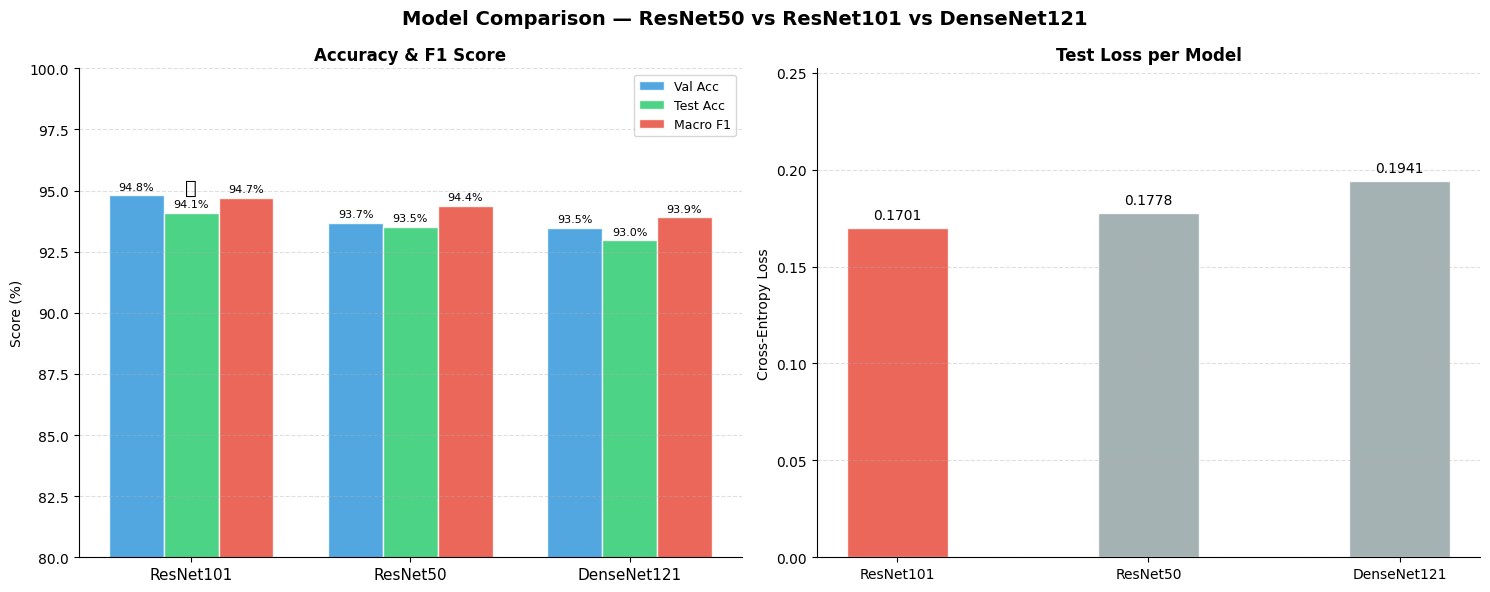

╔══════════════════════════════════════════════════════════════╗
║         📊  MODEL COMPARISON CHART COMPLETE                  ║
╠══════════════════════════════════════════════════════════════╣
║  Model            Val Acc   Test Acc       F1     Loss  ║
╠══════════════════════════════════════════════════════════════╣
║  🥇 ResNet101       94.80%    94.10%   94.70%  0.1701  ║
║  🥈 ResNet50        93.67%    93.53%   94.37%  0.1778  ║
║  🥉 DenseNet121     93.48%    92.96%   93.90%  0.1941  ║
╠══════════════════════════════════════════════════════════════╣
║  🏆 Best Model : ResNet101                                    ║
╠══════════════════════════════════════════════════════════════╣
║  💾 Saved → reports/model_comparison.png                    ║
╚══════════════════════════════════════════════════════════════╝


In [13]:
# ============================================================
#   CELL 12 — MODEL COMPARISON BAR CHART
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

models      = df_summary["Model"].tolist()
val_accs    = df_summary["Val Acc"].tolist()
test_accs   = df_summary["Test Acc"].tolist()
test_losses = df_summary["Test Loss"].tolist()

# F1 scores from classification reports
f1_scores = [all_reports[m]["macro avg"]["f1-score"] * 100 for m in models]

x     = np.arange(len(models))
width = 0.25
colors = ["#3498db", "#2ecc71", "#e74c3c"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Model Comparison — ResNet50 vs ResNet101 vs DenseNet121",
             fontsize=14, fontweight="bold")

# ── Left: Val Acc / Test Acc / F1 grouped bars ───────────────
bars1 = ax1.bar(x - width,   val_accs,   width, label="Val Acc",
                color=colors[0], alpha=0.85, edgecolor="white")
bars2 = ax1.bar(x,           test_accs,  width, label="Test Acc",
                color=colors[1], alpha=0.85, edgecolor="white")
bars3 = ax1.bar(x + width,   f1_scores,  width, label="Macro F1",
                color=colors[2], alpha=0.85, edgecolor="white")

ax1.set_title("Accuracy & F1 Score", fontweight="bold")
ax1.set_ylabel("Score (%)")
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.set_ylim(80, 100)
ax1.legend(fontsize=9)
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.spines[["top","right"]].set_visible(False)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.15,
                 f"{bar.get_height():.1f}%",
                 ha="center", va="bottom", fontsize=8)

# Best model annotation
best_idx = test_accs.index(max(test_accs))
ax1.annotate("🏆",
             xy=(best_idx, max(test_accs) + 0.8),
             ha="center", fontsize=14)

# ── Right: Test Loss ──────────────────────────────────────────
bar_colors = ["#e74c3c" if m == BEST_MODEL_NAME else "#95a5a6" for m in models]
bars4 = ax2.bar(models, test_losses, color=bar_colors,
                alpha=0.85, edgecolor="white", width=0.4)

ax2.set_title("Test Loss per Model", fontweight="bold")
ax2.set_ylabel("Cross-Entropy Loss")
ax2.set_ylim(0, max(test_losses) * 1.3)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.spines[["top","right"]].set_visible(False)

for bar in bars4:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{bar.get_height():.4f}",
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(f"{REPORTS}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║         📊  MODEL COMPARISON CHART COMPLETE                  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Val Acc':>9} {'Test Acc':>10} {'F1':>8} {'Loss':>8}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
medals = ["🥇","🥈","🥉"]
for i, row in df_summary.iterrows():
    f1 = all_reports[row["Model"]]["macro avg"]["f1-score"] * 100
    print(f"║  {medals[i]} {row['Model']:<13}"
          f"{row['Val Acc']:>8.2f}% "
          f"{row['Test Acc']:>8.2f}% "
          f"{f1:>7.2f}% "
          f"{row['Test Loss']:>7.4f}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  🏆 Best Model : {BEST_MODEL_NAME:<45}║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/model_comparison.png                    ║")
print("╚══════════════════════════════════════════════════════════════╝")

In [14]:
# ============================================================
#   CELL 13 — VERIFY SAVED WEIGHTS
# ============================================================
import os

files = [f for f in os.listdir(WEIGHTS)]

print("╔══════════════════════════════════════════════════════╗")
print("║         💾  SAVED WEIGHTS — VERIFICATION             ║")
print("╠══════════════════════════════════════════════════════╣")
for f in sorted(files):
    size = os.path.getsize(os.path.join(WEIGHTS, f)) / (1024 * 1024)
    print(f"║  📄 {f:<38} {size:>5.1f} MB  ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📁 Path : {WEIGHTS[-50:]:<51}║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║         💾  SAVED WEIGHTS — VERIFICATION             ║
╠══════════════════════════════════════════════════════╣
║  📄 DenseNet121_checkpoint_20260420_054257.pth  28.1 MB  ║
║  📄 ResNet101_20260419_084538.pth          164.7 MB  ║
║  📄 ResNet101_checkpoint_20260419_084538.pth 164.7 MB  ║
║  📄 ResNet50_checkpoint_20260420_051503.pth  92.0 MB  ║
║  📄 model_meta.json                          0.0 MB  ║
╠══════════════════════════════════════════════════════╣
║  📁 Path : /content/drive/MyDrive/chest_xray_project/weights  ║
╚══════════════════════════════════════════════════════╝


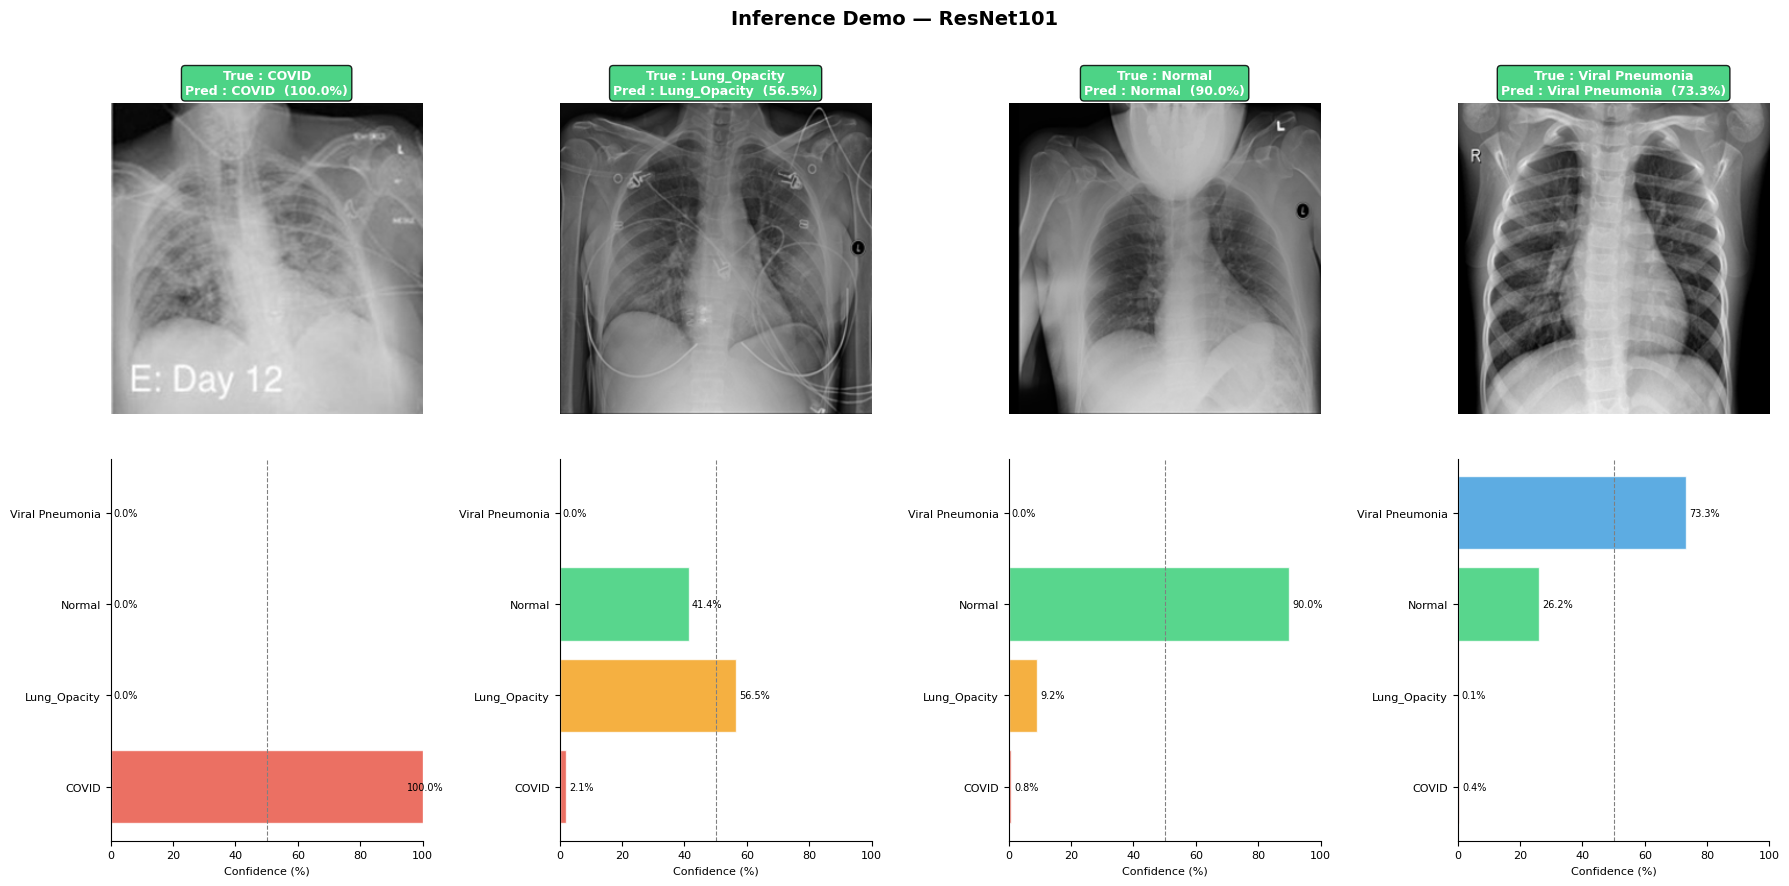

╔══════════════════════════════════════════════════════════════╗
║        🔍  INFERENCE DEMO — ResNet101                         ║
╠══════════════════════════════════════════════════════════════╣
║  True Label         Predicted              Conf   Result  ║
╠══════════════════════════════════════════════════════════════╣
║  COVID              COVID               100.0%  ✅ Correct ║
║  Lung_Opacity       Lung_Opacity         56.5%  ✅ Correct ║
║  Normal             Normal               90.0%  ✅ Correct ║
║  Viral Pneumonia    Viral Pneumonia      73.3%  ✅ Correct ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ Correct : 4/4                                                ║
╠══════════════════════════════════════════════════════════════╣
║  💾 Saved → reports/inference_demo.png                      ║
╚══════════════════════════════════════════════════════════════╝


In [15]:
# ============================================================
#   CELL 14 — SINGLE IMAGE INFERENCE DEMO
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import torch, os, random
import torch.nn.functional as F

# ── Inference transform (no augmentation) ────────────────────
infer_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

def predict_image(img_path, model):
    model.eval()
    img    = Image.open(img_path).convert("RGB")
    tensor = infer_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(tensor)
        probs  = F.softmax(output, dim=1).squeeze().cpu().numpy()
    pred_idx   = probs.argmax()
    pred_label = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx] * 100
    return img, pred_label, confidence, probs

# ── Pick one random image per class ──────────────────────────
CLASS_COLORS = {
    "COVID"           : "#e74c3c",
    "Lung_Opacity"    : "#f39c12",
    "Normal"          : "#2ecc71",
    "Viral Pneumonia" : "#3498db"
}

sample_images = []
for cls in CLASS_NAMES:
    img_dir = os.path.join(DATA_PATH, cls, "images")
    if not os.path.exists(img_dir):
        img_dir = os.path.join(DATA_PATH, cls)
    fname = random.choice(os.listdir(img_dir))
    sample_images.append((os.path.join(img_dir, fname), cls))

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(f"Inference Demo — {BEST_MODEL_NAME}",
             fontsize=14, fontweight="bold")

results = []
for i, (img_path, true_label) in enumerate(sample_images):
    img, pred_label, confidence, probs = predict_image(img_path, BEST_MODEL)

    correct = pred_label == true_label
    color   = "#2ecc71" if correct else "#e74c3c"

    # ── Image ─────────────────────────────────────────────────
    ax_img = axes[0][i]
    ax_img.imshow(img, cmap="gray")
    ax_img.set_title(
        f"True : {true_label}\nPred : {pred_label}  ({confidence:.1f}%)",
        fontsize=9, fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.85)
    )
    ax_img.axis("off")

    # ── Probability bar ───────────────────────────────────────
    ax_bar = axes[1][i]
    bar_colors = [CLASS_COLORS[c] for c in CLASS_NAMES]
    bars = ax_bar.barh(CLASS_NAMES, probs * 100,
                       color=bar_colors, alpha=0.8, edgecolor="white")
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Confidence (%)", fontsize=8)
    ax_bar.axvline(x=50, color="gray", linestyle="--", linewidth=0.8)
    ax_bar.spines[["top","right"]].set_visible(False)
    ax_bar.tick_params(labelsize=8)
    for bar, prob in zip(bars, probs):
        ax_bar.text(min(prob*100 + 1, 95), bar.get_y() + bar.get_height()/2,
                    f"{prob*100:.1f}%", va="center", fontsize=7)

    results.append({
        "true": true_label, "pred": pred_label,
        "conf": confidence, "correct": correct
    })

plt.tight_layout()
plt.savefig(f"{REPORTS}/inference_demo.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print(f"║        🔍  INFERENCE DEMO — {BEST_MODEL_NAME:<34}║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'True Label':<18} {'Predicted':<18} {'Conf':>8} {'Result':>8}  ║")
print("╠══════════════════════════════════════════════════════════════╣")
for r in results:
    status = "✅ Correct" if r["correct"] else "❌ Wrong"
    print(f"║  {r['true']:<18} {r['pred']:<18} {r['conf']:>6.1f}%  {status:<10}║")
print("╠══════════════════════════════════════════════════════════════╣")
correct_count = sum(r["correct"] for r in results)
print(f"║  ✅ Correct : {correct_count}/{len(results)}{' '*48}║"[:66]+"║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/inference_demo.png                      ║")
print("╚══════════════════════════════════════════════════════════════╝")

# Phase 3

In [16]:
# ============================================================
#   CELL 15 — ENSEMBLE (WEIGHTED SOFTMAX AVERAGING)
# ============================================================
import torch
import torch.nn.functional as F

# ── Ensemble weights ──────────────────────────────────────────
ENSEMBLE_WEIGHTS = {
    "ResNet50"    : 0.30,
    "ResNet101"   : 0.30,
    "DenseNet121" : 0.40,
}

def ensemble_predict(loaders, trained_models, weights):
    all_probs  = {name: [] for name in trained_models}
    all_labels = []
    collected  = False

    for name, (model, _, _) in trained_models.items():
        model.eval()
        with torch.no_grad():
            for images, labels in loaders:
                images = images.to(DEVICE)
                logits = model(images)
                probs  = F.softmax(logits, dim=1).cpu()
                all_probs[name].append(probs)
                if not collected:
                    all_labels.append(labels)
        collected = True

    # Stack per model
    for name in all_probs:
        all_probs[name] = torch.cat(all_probs[name], dim=0)

    labels_all = torch.cat(all_labels, dim=0)

    # Weighted average
    ensemble_probs = sum(
        all_probs[name] * weights[name]
        for name in all_probs
    )

    preds = ensemble_probs.argmax(dim=1)
    acc   = (preds == labels_all).float().mean().item()
    return ensemble_probs, preds.numpy(), labels_all.numpy(), acc


print("╔══════════════════════════════════════════════════════════════╗")
print("║         🤝  ENSEMBLE SETUP READY                             ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Strategy : Weighted Softmax Averaging                       ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<14} {'Weight':>8} {'Contribution':>14}          ║")
print("╠══════════════════════════════════════════════════════════════╣")
for name, w in ENSEMBLE_WEIGHTS.items():
    bar = "█" * int(w * 20)
    print(f"║  {name:<14} {w:>7.0%}   {bar:<20}              ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Formula:                                                    ║")
print("║  P_final = 0.30×P(R50) + 0.30×P(R101) + 0.40×P(DN121)      ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  ✅ ensemble_predict() ready                                 ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║         🤝  ENSEMBLE SETUP READY                             ║
╠══════════════════════════════════════════════════════════════╣
║  Strategy : Weighted Softmax Averaging                       ║
╠══════════════════════════════════════════════════════════════╣
║  Model            Weight   Contribution          ║
╠══════════════════════════════════════════════════════════════╣
║  ResNet50           30%   ██████                            ║
║  ResNet101          30%   ██████                            ║
║  DenseNet121        40%   ████████                          ║
╠══════════════════════════════════════════════════════════════╣
║  Formula:                                                    ║
║  P_final = 0.30×P(R50) + 0.30×P(R101) + 0.40×P(DN121)      ║
╠══════════════════════════════════════════════════════════════╣
║  ✅ ensemble_predict() ready                                 ║
╚═══════════════════════════════════════════

In [17]:
# ============================================================
#   CELL 16 — ENSEMBLE EVALUATION + COMPARISON
# ============================================================
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# ── Run ensemble on test set ──────────────────────────────────
print("⏳ Running ensemble on test set...")
ens_probs, ens_preds, ens_labels, ens_acc = ensemble_predict(
    test_loader, TRAINED_MODELS, ENSEMBLE_WEIGHTS
)
print("✅ Done!\n")

# ── Run ensemble on val set ───────────────────────────────────
print("⏳ Running ensemble on val set...")
_, _, ens_val_labels, ens_val_acc = ensemble_predict(
    val_loader, TRAINED_MODELS, ENSEMBLE_WEIGHTS
)
print("✅ Done!\n")

# ── F1 scores ─────────────────────────────────────────────────
ens_report  = classification_report(
    ens_labels, ens_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)
ens_f1      = ens_report["macro avg"]["f1-score"] * 100
ens_test_acc = ens_acc * 100
ens_val_acc  = ens_val_acc * 100

# ── Build comparison table ────────────────────────────────────
rows = []
for name, row in zip(df_summary["Model"], df_summary.itertuples()):
    f1 = all_reports[name]["macro avg"]["f1-score"] * 100
    rows.append({
        "Model"    : name,
        "Val Acc"  : row._2,
        "Test Acc" : row._3,
        "Macro F1" : f1,
    })

# Add ensemble row
rows.append({
    "Model"    : "🤝 Ensemble",
    "Val Acc"  : ens_val_acc,
    "Test Acc" : ens_test_acc,
    "Macro F1" : ens_f1,
})

df_compare = pd.DataFrame(rows).sort_values("Test Acc", ascending=False).reset_index(drop=True)
df_compare.to_csv(f"{REPORTS}/ensemble_comparison.csv", index=False)

# ── Output ────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════════╗")
print("║         🤝  ENSEMBLE vs INDIVIDUAL — COMPARISON                 ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  {'Model':<16} {'Val Acc':>10} {'Test Acc':>10} {'Macro F1':>10}      ║")
print("╠══════════════════════════════════════════════════════════════════╣")

medals = ["🥇","🥈","🥉","4️⃣ "]
for i, row in df_compare.iterrows():
    medal  = medals[i] if i < 4 else "   "
    is_ens = "←★" if row["Model"] == "🤝 Ensemble" else "  "
    print(f"║  {medal} {row['Model']:<15}"
          f"{row['Val Acc']:>8.2f}%  "
          f"{row['Test Acc']:>8.2f}%  "
          f"{row['Macro F1']:>8.2f}%  {is_ens}  ║")

print("╠══════════════════════════════════════════════════════════════════╣")

# Gain over best individual
best_individual = df_summary.iloc[0]["Test Acc"]
gain            = ens_test_acc - best_individual
gain_str        = f"+{gain:.2f}%" if gain >= 0 else f"{gain:.2f}%"
verdict         = "✅ Ensemble WINS" if gain >= 0 else "⚠️  Best individual wins"

print(f"║  📈 Gain over best individual : {gain_str:<34}║")
print(f"║  {verdict:<65}║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/ensemble_comparison.csv                    ║")
print("╚══════════════════════════════════════════════════════════════════╝")

⏳ Running ensemble on test set...
✅ Done!

⏳ Running ensemble on val set...
✅ Done!

╔══════════════════════════════════════════════════════════════════╗
║         🤝  ENSEMBLE vs INDIVIDUAL — COMPARISON                 ║
╠══════════════════════════════════════════════════════════════════╣
║  Model               Val Acc   Test Acc   Macro F1      ║
╠══════════════════════════════════════════════════════════════════╣
║  🥇 🤝 Ensemble        94.85%     94.43%     95.12%  ←★  ║
║  🥈 ResNet101         94.80%     94.10%     94.70%      ║
║  🥉 ResNet50          93.67%     93.53%     94.37%      ║
║  4️⃣  DenseNet121       93.48%     92.96%     93.90%      ║
╠══════════════════════════════════════════════════════════════════╣
║  📈 Gain over best individual : +0.33%                            ║
║  ✅ Ensemble WINS                                                  ║
╠══════════════════════════════════════════════════════════════════╣
║  💾 Saved → reports/ensemble_comparison.csv                    ║

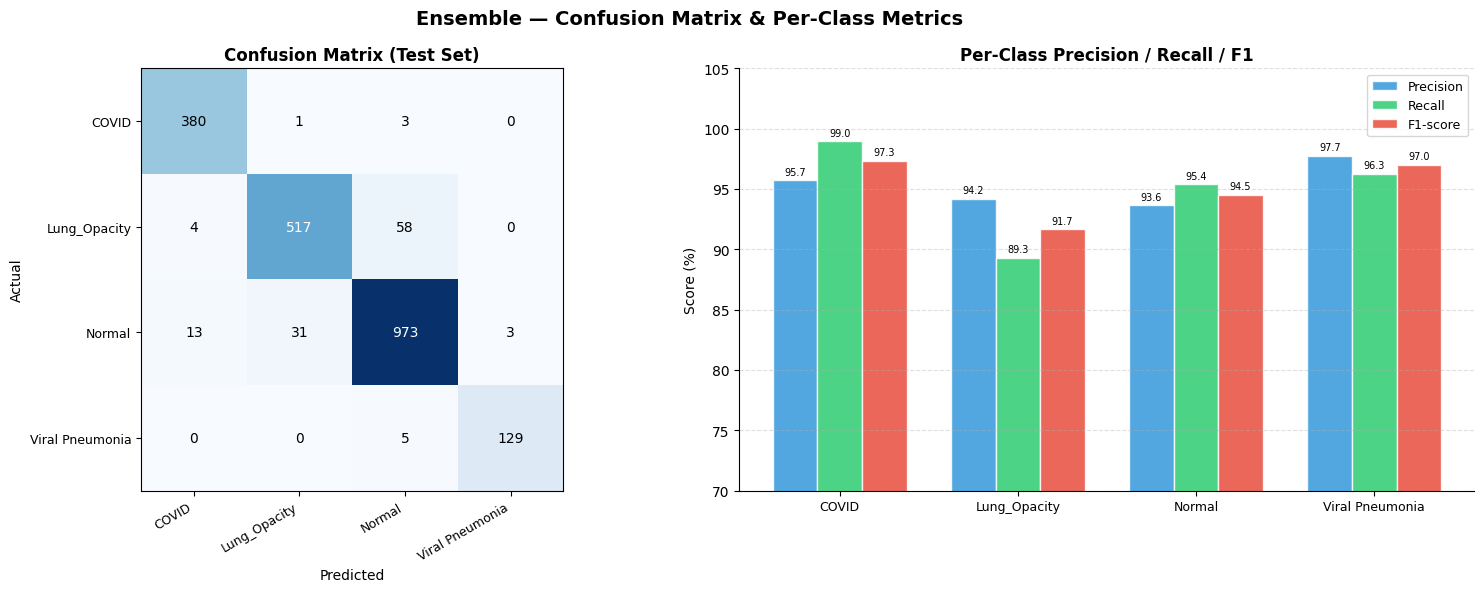

╔══════════════════════════════════════════════════════════════════════╗
║       🤝  ENSEMBLE — CLASSIFICATION REPORT                          ║
╠══════════════╦═════════════╦════════════╦══════════════╦════════════╣
║  Class       ║  Precision  ║   Recall   ║   F1-Score   ║  Support   ║
╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣
║  COVID         ║    95.72%   ║   98.96%  ║     97.31%    ║       384  ║
║  Lung_Opacity  ║    94.17%   ║   89.29%  ║     91.67%    ║       579  ║
║  Normal        ║    93.65%   ║   95.39%  ║     94.51%    ║      1020  ║
║  Viral Pneumonia  ║    97.73%   ║   96.27%  ║     96.99%    ║       134  ║
╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣
║  Macro Avg     ║    95.32%   ║   94.98%  ║     95.12%    ║            ║
╠══════════════╩═════════════╩════════════╩══════════════╩════════════╣
║  ✅ Ensemble Accuracy : 94.43%                                        ║
╠═════════════════════════════════════════════════

In [18]:
# ============================================================
#   CELL 17 — ENSEMBLE CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import itertools, pandas as pd

# ── Confusion Matrix ──────────────────────────────────────────
cm = confusion_matrix(ens_labels, ens_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Ensemble — Confusion Matrix & Per-Class Metrics",
             fontsize=14, fontweight="bold")

# ── Left: Confusion Matrix ────────────────────────────────────
ax = axes[0]
ax.imshow(cm, interpolation="nearest", cmap="Blues")
ax.set_title("Confusion Matrix (Test Set)", fontweight="bold")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("Actual",    fontsize=10)
thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, f"{cm[i,j]}",
            ha="center", va="center", fontsize=10,
            color="white" if cm[i,j] > thresh else "black")

# ── Right: Per-Class Bar Chart ────────────────────────────────
ax2     = axes[1]
report  = classification_report(
    ens_labels, ens_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

metrics     = ["precision", "recall", "f1-score"]
x           = np.arange(len(CLASS_NAMES))
width       = 0.25
bar_colors  = ["#3498db", "#2ecc71", "#e74c3c"]

for i, metric in enumerate(metrics):
    vals = [report[cls][metric] * 100 for cls in CLASS_NAMES]
    bars = ax2.bar(x + i * width, vals, width,
                   label=metric.capitalize(),
                   color=bar_colors[i], alpha=0.85, edgecolor="white")
    for bar in bars:
        ax2.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f"{bar.get_height():.1f}",
                 ha="center", va="bottom", fontsize=7)

ax2.set_title("Per-Class Precision / Recall / F1", fontweight="bold")
ax2.set_ylabel("Score (%)")
ax2.set_xticks(x + width)
ax2.set_xticklabels(CLASS_NAMES, fontsize=9)
ax2.set_ylim(70, 105)
ax2.legend(fontsize=9)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{REPORTS}/ensemble_confusion_report.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Save CSV ──────────────────────────────────────────────────
rows = []
for cls in CLASS_NAMES:
    rows.append({
        "Class"    : cls,
        "Precision": round(report[cls]["precision"], 4),
        "Recall"   : round(report[cls]["recall"],    4),
        "F1-Score" : round(report[cls]["f1-score"],  4),
        "Support"  : int(report[cls]["support"]),
    })
df_ens_report = pd.DataFrame(rows)
df_ens_report.to_csv(f"{REPORTS}/ensemble_classification_report.csv", index=False)

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════════════╗")
print("║       🤝  ENSEMBLE — CLASSIFICATION REPORT                          ║")
print("╠══════════════╦═════════════╦════════════╦══════════════╦════════════╣")
print("║  Class       ║  Precision  ║   Recall   ║   F1-Score   ║  Support   ║")
print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")
for cls in CLASS_NAMES:
    p  = report[cls]["precision"] * 100
    r  = report[cls]["recall"]    * 100
    f1 = report[cls]["f1-score"]  * 100
    s  = int(report[cls]["support"])
    print(f"║  {cls:<12}  ║  {p:>7.2f}%   ║  {r:>6.2f}%  ║   {f1:>7.2f}%    ║  {s:>8}  ║")
print("╠══════════════╬═════════════╬════════════╬══════════════╬════════════╣")
ma_p  = report["macro avg"]["precision"]   * 100
ma_r  = report["macro avg"]["recall"]      * 100
ma_f1 = report["macro avg"]["f1-score"]    * 100
acc   = report["accuracy"]                 * 100
print(f"║  {'Macro Avg':<12}  ║  {ma_p:>7.2f}%   ║  {ma_r:>6.2f}%  ║   {ma_f1:>7.2f}%    ║            ║")
print("╠══════════════╩═════════════╩════════════╩══════════════╩════════════╣")
print(f"║  ✅ Ensemble Accuracy : {acc:.2f}%{' '*(46 - len(f'{acc:.2f}%'))}║")
print("╠══════════════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → reports/ensemble_confusion_report.png                  ║")
print(f"║  💾 Saved → reports/ensemble_classification_report.csv            ║")
print("╚══════════════════════════════════════════════════════════════════════╝")

In [19]:
# ============================================================
#   CELL 18 — SAVE ENSEMBLE CONFIG
# ============================================================
import json, os
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ── Save ensemble config ──────────────────────────────────────
ensemble_config = {
    "timestamp"        : timestamp,
    "strategy"         : "weighted_softmax_average",
    "weights"          : ENSEMBLE_WEIGHTS,
    "class_names"      : CLASS_NAMES,
    "num_classes"      : NUM_CLASSES,
    "img_size"         : IMG_SIZE,
    "normalize"        : {
        "mean" : [0.485, 0.456, 0.406],
        "std"  : [0.229, 0.224, 0.225]
    },
    "models"           : {},
    "ensemble_metrics" : {
        "test_acc"  : round(ens_test_acc, 4),
        "val_acc"   : round(ens_val_acc,  4),
        "macro_f1"  : round(ens_f1,       4),
    }
}

# Add per-model checkpoint references
for name in TRAINED_MODELS:
    ckpt_files = sorted([
        f for f in os.listdir(WEIGHTS)
        if name in f and "checkpoint" in f
    ])
    ensemble_config["models"][name] = {
        "checkpoint"   : ckpt_files[-1] if ckpt_files else "not found",
        "weight"       : ENSEMBLE_WEIGHTS[name],
        "test_acc"     : round(float(
            df_summary[df_summary["Model"] == name]["Test Acc"].values[0]
        ), 4),
    }

config_path = f"{WEIGHTS}/ensemble_config.json"
with open(config_path, "w") as f:
    json.dump(ensemble_config, f, indent=4)

# ── Console Output ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║         💾  ENSEMBLE CONFIG SAVED                            ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  📅 Timestamp   : {timestamp:<44}║")
print(f"║  ⚙️  Strategy    : Weighted Softmax Average{' '*21}║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  🧠 Models & Weights :                                       ║")
for name, info in ensemble_config["models"].items():
    print(f"║     {name:<14} → weight: {info['weight']}  "
          f"test_acc: {info['test_acc']:.2f}%{' '*10}║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📊 Ensemble Metrics :                                       ║")
print(f"║     ✅ Test Acc  : {ens_test_acc:.2f}%{' '*43}║"[:66]+"║")
print(f"║     ✅ Val Acc   : {ens_val_acc:.2f}%{' '*43}║"[:66]+"║")
print(f"║     ✅ Macro F1  : {ens_f1:.2f}%{' '*43}║"[:66]+"║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📁 Weights folder now contains :                            ║")
for f in sorted(os.listdir(WEIGHTS)):
    size = os.path.getsize(os.path.join(WEIGHTS, f)) / (1024*1024)
    print(f"║     📄 {f:<38} {size:>5.1f} MB  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  💾 Saved → weights/ensemble_config.json                    ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  🔜 Phase 3 Complete → Phase 4: Book Indexing starts next    ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║         💾  ENSEMBLE CONFIG SAVED                            ║
╠══════════════════════════════════════════════════════════════╣
║  📅 Timestamp   : 20260420_102228                             ║
║  ⚙️  Strategy    : Weighted Softmax Average                     ║
╠══════════════════════════════════════════════════════════════╣
║  🧠 Models & Weights :                                       ║
║     ResNet50       → weight: 0.3  test_acc: 93.53%          ║
║     ResNet101      → weight: 0.3  test_acc: 94.10%          ║
║     DenseNet121    → weight: 0.4  test_acc: 92.96%          ║
╠══════════════════════════════════════════════════════════════╣
║  📊 Ensemble Metrics :                                       ║
║     ✅ Test Acc  : 94.43%                                        ║
║     ✅ Val Acc   : 94.85%                                        ║
║     ✅ Macro F1  : 95.12%                                        ║
╠══════════════════

In [20]:
# ============================================================
#   CELL 19 — INSTALL RAG DEPENDENCIES
# ============================================================
import subprocess, sys

packages = [
    "langchain",
    "langchain-community",
    "langchain-chroma",
    "langchain-huggingface",
    "chromadb",
    "sentence-transformers",
    "rank_bm25",
    "pymupdf",            # PDF loader (fitz)
    "pypdf",              # fallback PDF loader
    "langchain-openai",   # for GPT-4o (optional)
    "langchain-google-genai",  # for Gemini (optional)
]

print("╔══════════════════════════════════════════════════════╗")
print("║   📦  INSTALLING RAG DEPENDENCIES                    ║")
print("╠══════════════════════════════════════════════════════╣")

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "✅" if result.returncode == 0 else "❌"
    print(f"║  {status}  {pkg:<45}  ║")

print("╠══════════════════════════════════════════════════════╣")
print("║  🎉 All dependencies installed!                      ║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║   📦  INSTALLING RAG DEPENDENCIES                    ║
╠══════════════════════════════════════════════════════╣
║  ✅  langchain                                      ║
║  ✅  langchain-community                            ║
║  ✅  langchain-chroma                               ║
║  ✅  langchain-huggingface                          ║
║  ✅  chromadb                                       ║
║  ✅  sentence-transformers                          ║
║  ✅  rank_bm25                                      ║
║  ✅  pymupdf                                        ║
║  ✅  pypdf                                          ║
║  ✅  langchain-openai                               ║
║  ✅  langchain-google-genai                         ║
╠══════════════════════════════════════════════════════╣
║  🎉 All dependencies installed!                      ║
╚══════════════════════════════════════════════════════╝


In [21]:
# ============================================================
#   CELL 20 — LOAD MEDICAL PDF (Google Drive Mount)
# ============================================================
from google.colab import drive
import fitz, os

# ── Mount Drive ───────────────────────────────────────────────
drive.mount('/drive')

# ── CONFIG ────────────────────────────────────────────────────
PDF_FILENAME = "medical_book.pdf"
PDF_PATH     = f"/drive/MyDrive/chest_xray_project/books/{PDF_FILENAME}"
CHROMA_DIR   = "/drive/MyDrive/chest_xray_project/chroma_db"
COLLECTION   = "medical_book"

os.makedirs(CHROMA_DIR, exist_ok=True)

# ── Verify PDF exists ─────────────────────────────────────────
if not os.path.exists(PDF_PATH):
    raise FileNotFoundError(
        f"\n❌ PDF not found at: {PDF_PATH}"
        f"\n👉 Make sure '{PDF_FILENAME}' is inside:"
        f"\n   chest_xray_project/books/ in your Google Drive"
    )

# ── Load raw pages ────────────────────────────────────────────
def load_pdf_pages(path):
    doc   = fitz.open(path)
    pages = []
    for i, page in enumerate(doc):
        text = page.get_text("text").strip()
        if len(text) > 100:
            pages.append({
                "page_num" : i + 1,
                "text"     : text,
                "source"   : os.path.basename(path),
            })
    doc.close()
    return pages

raw_pages = load_pdf_pages(PDF_PATH)

print("╔══════════════════════════════════════════════════════════╗")
print("║   📖  MEDICAL PDF LOADED FROM GOOGLE DRIVE               ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  📄 File        : {PDF_FILENAME:<42}║")
print(f"║  📂 Drive Path  : chest_xray_project/books/{PDF_FILENAME:<10}║")
print(f"║  📃 Pages loaded: {len(raw_pages):<42}║")
print(f"║  📝 Total chars : {sum(len(p['text']) for p in raw_pages):<42,}║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Sample (Page 1):")
print(f"║  {raw_pages[0]['text'][:110].replace(chr(10),' '):<56}  ║")
print("╚══════════════════════════════════════════════════════════╝")

Mounted at /drive
╔══════════════════════════════════════════════════════════╗
║   📖  MEDICAL PDF LOADED FROM GOOGLE DRIVE               ║
╠══════════════════════════════════════════════════════════╣
║  📄 File        : medical_book.pdf                          ║
║  📂 Drive Path  : chest_xray_project/books/medical_book.pdf║
║  📃 Pages loaded: 156                                       ║
║  📝 Total chars : 204,596                                   ║
╠══════════════════════════════════════════════════════════╣
║  Sample (Page 1):
║  1600 John F. Kennedy Blvd. Ste 1800 Phildelphia, PA 19103-2899 FELSON’S PRINCIPLES OF CHEST ROENTGENOLOGY ISBN  ║
╚══════════════════════════════════════════════════════════╝


In [22]:
# ============================================================
#   CELL 21 — SEMANTIC CHUNKER → SPLIT INTO CHUNKS
# ============================================================
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

# ── Chunking strategy ─────────────────────────────────────────
CHUNK_SIZE    = 800
CHUNK_OVERLAP = 80

splitter = RecursiveCharacterTextSplitter(
    chunk_size      = CHUNK_SIZE,
    chunk_overlap   = CHUNK_OVERLAP,
    separators      = ["\n\n", "\n", ". ", "! ", "? ", " ", ""],
    length_function = len,
)

# ── Convert pages → LangChain Documents ──────────────────────
docs = []
for page in raw_pages:
    chunks = splitter.split_text(page["text"])
    for i, chunk in enumerate(chunks):
        docs.append(Document(
            page_content = chunk,
            metadata     = {
                "source"    : page["source"],   # which book it came from
                "page_num"  : page["page_num"],
                "chunk_idx" : i,
            }
        ))

# ── Stats per book ────────────────────────────────────────────
from collections import Counter
source_counts = Counter(d.metadata["source"] for d in docs)

print("╔══════════════════════════════════════════════════════════════╗")
print("║   ✂️   SEMANTIC CHUNKER COMPLETE                              ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  📃 Raw pages     : {len(raw_pages):<42}║")
print(f"║  🧩 Total chunks  : {len(docs):<42}║")
print(f"║  📏 Chunk size    : {CHUNK_SIZE} chars  |  Overlap : {CHUNK_OVERLAP} chars{' '*15}║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  📚 Chunks per book :                                        ║")
for source, count in source_counts.items():
    print(f"║     📖 {source:<35} → {count:>5} chunks  ║")
print("╠══════════════════════════════════════════════════════════════╣")
avg_len = sum(len(d.page_content) for d in docs) / len(docs)
print(f"║  📊 Avg chunk len : {avg_len:.0f} chars{' '*38}║"[:65]+"║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Sample chunk (Book 1, Chunk 1) :")
print(f"║  {docs[0].page_content[:110].replace(chr(10),' '):<60}║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║   ✂️   SEMANTIC CHUNKER COMPLETE                              ║
╠══════════════════════════════════════════════════════════════╣
║  📃 Raw pages     : 156                                       ║
║  🧩 Total chunks  : 350                                       ║
║  📏 Chunk size    : 800 chars  |  Overlap : 80 chars               ║
╠══════════════════════════════════════════════════════════════╣
║  📚 Chunks per book :                                        ║
║     📖 medical_book.pdf                    →   350 chunks  ║
╠══════════════════════════════════════════════════════════════╣
║  📊 Avg chunk len : 615 chars                                   ║
╠══════════════════════════════════════════════════════════════╣
║  Sample chunk (Book 1, Chunk 1) :
║  1600 John F. Kennedy Blvd. Ste 1800 Phildelphia, PA 19103-2899 FELSON’S PRINCIPLES OF CHEST ROENTGENOLOGY ISBN║
╚══════════════════════════════════════════════════════════════╝


In [23]:
# ============================================================
#   CELL 22 — EMBED CHUNKS → STORE IN CHROMADB
# ============================================================
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
import torch, time, os

# ── Embedding model ───────────────────────────────────────────
EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"   # 80MB, fast + accurate
# Upgrade option → "BAAI/bge-base-en-v1.5"               # 110MB, higher quality

BATCH_SIZE  = 512

# ── Check if ChromaDB already exists (skip re-indexing) ──────
chroma_exists = (
    os.path.exists(CHROMA_DIR) and
    len(os.listdir(CHROMA_DIR)) > 0
)

if chroma_exists:
    print("╔══════════════════════════════════════════════════════════╗")
    print("║   ⚡  CHROMADB ALREADY EXISTS — LOADING FROM DRIVE       ║")
    print("╠══════════════════════════════════════════════════════════╣")

    embeddings  = HuggingFaceEmbeddings(
        model_name    = EMBED_MODEL,
        model_kwargs  = {"device": "cuda" if torch.cuda.is_available() else "cpu"},
        encode_kwargs = {"normalize_embeddings": True},
    )
    vectorstore = Chroma(
        collection_name    = COLLECTION,
        embedding_function = embeddings,
        persist_directory  = CHROMA_DIR,
    )
    total = vectorstore._collection.count()
    print(f"║  📦 Collection  : {COLLECTION:<42}║")
    print(f"║  🧩 Chunks      : {total:<42}║")
    print(f"║  📁 Path        : {CHROMA_DIR[-50:]:<42}║")
    print("╠══════════════════════════════════════════════════════════╣")
    print("║  ✅ Skipped re-indexing — already up to date             ║")
    print("╚══════════════════════════════════════════════════════════╝")

else:
    # ── Fresh index ───────────────────────────────────────────
    print("╔══════════════════════════════════════════════════════════╗")
    print("║   🔢  LOADING EMBEDDING MODEL …                          ║")
    print("╚══════════════════════════════════════════════════════════╝")

    embeddings = HuggingFaceEmbeddings(
        model_name    = EMBED_MODEL,
        model_kwargs  = {"device": "cuda" if torch.cuda.is_available() else "cpu"},
        encode_kwargs = {"normalize_embeddings": True},
    )

    print("╔══════════════════════════════════════════════════════════════╗")
    print("║   💾  EMBEDDING & STORING IN CHROMADB …                      ║")
    print("╠══════════════════════════════════════════════════════════════╣")

    vectorstore = Chroma(
        collection_name    = COLLECTION,
        embedding_function = embeddings,
        persist_directory  = CHROMA_DIR,
    )

    start_time = time.time()

    for i in range(0, len(docs), BATCH_SIZE):
        batch = docs[i : i + BATCH_SIZE]
        vectorstore.add_documents(batch)
        pct  = min((i + BATCH_SIZE) / len(docs) * 100, 100)
        done = min(i + BATCH_SIZE, len(docs))
        bar  = "█" * int(pct // 5) + "░" * (20 - int(pct // 5))
        print(f"║  [{bar}] {pct:>5.1f}%  {done:>5}/{len(docs)} chunks{' '*10}║")

    elapsed = time.time() - start_time

    print("╠══════════════════════════════════════════════════════════════╣")
    print(f"║  ✅ Stored {len(docs):>5} chunks in ChromaDB{' '*22}║")
    print(f"║  ⏱️  Time     : {elapsed:.1f}s{' '*46}║"[:67]+"║")
    print(f"║  📁 Saved to : chest_xray_project/chroma_db{' '*20}║")
    print("╠══════════════════════════════════════════════════════════════╣")
    print("║  💡 Next session → loads instantly, no re-indexing needed    ║")
    print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════╗
║   ⚡  CHROMADB ALREADY EXISTS — LOADING FROM DRIVE       ║
╠══════════════════════════════════════════════════════════╣


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


║  📦 Collection  : medical_book                              ║
║  🧩 Chunks      : 350                                       ║
║  📁 Path        : /drive/MyDrive/chest_xray_project/chroma_db║
╠══════════════════════════════════════════════════════════╣
║  ✅ Skipped re-indexing — already up to date             ║
╚══════════════════════════════════════════════════════════╝


In [24]:
# ============================================================
#   CELL 23 — TEST RETRIEVAL (QUERY CHROMADB)
# ============================================================

# ── Test queries — one per class ─────────────────────────────
test_queries = {
    "COVID-19"      : "COVID-19 chest X-ray ground glass opacity bilateral infiltrates",
    "Lung Opacity"  : "lung opacity consolidation pleural effusion radiograph",
    "Normal"        : "normal chest X-ray lung appearance clear fields",
    "Viral Pneumonia": "viral pneumonia interstitial pattern peribronchial thickening",
}

retriever = vectorstore.as_retriever(
    search_type   = "mmr",           # Maximal Marginal Relevance — diverse results
    search_kwargs = {"k": 4, "fetch_k": 20},
)

print("╔══════════════════════════════════════════════════════════════════╗")
print("║   🔍  CHROMADB RETRIEVAL TEST — ALL 4 CLASSES                    ║")
print("╠══════════════════════════════════════════════════════════════════╣")

all_passed = True

for cls, query in test_queries.items():
    results = retriever.invoke(query)

    if len(results) == 0:
        all_passed = False
        print(f"║  ❌  {cls:<15} → NO RESULTS FOUND{' '*28}║")
        continue

    print(f"║                                                                  ║")
    print(f"║  🏷️  Class   : {cls:<51}║")
    print(f"║  🔎 Query   : {query[:51]:<51}║")
    print(f"║  {'─'*64}║")

    for i, doc in enumerate(results[:2]):           # show top 2 per query
        source  = doc.metadata.get("source", "unknown")[:25]
        pg      = doc.metadata.get("page_num", "?")
        snippet = doc.page_content[:90].replace("\n", " ")
        print(f"║  [{i+1}] 📖 {source:<25} p.{pg:<4} →  {snippet[:28]}…  ║")

    print(f"║  ✅ Retrieved {len(results)} chunks{' '*48}║"[:68]+"║")

print("║                                                                  ║")
print("╠══════════════════════════════════════════════════════════════════╣")

# ── Summary stats ─────────────────────────────────────────────
total_docs = vectorstore._collection.count()
from collections import Counter

# Check source distribution in a sample retrieval
sample     = retriever.invoke("chest X-ray radiological findings")
src_counts = Counter(d.metadata.get("source","?") for d in sample)

print(f"║  📦 Total chunks in DB  : {total_docs:<40}║")
print(f"║  📚 Source distribution (sample retrieval):                      ║")
for src, cnt in src_counts.items():
    print(f"║     📖 {src:<35} → {cnt} chunks  ║")
print("╠══════════════════════════════════════════════════════════════════╣")
if all_passed:
    print("║  🎉 ALL QUERIES RETURNED RESULTS — ChromaDB healthy!             ║")
else:
    print("║  ⚠️  Some queries returned no results — check PDF content        ║")
print("║  🔜 Ready for Phase 5 → Hybrid Search + LLM Report               ║")
print("╚══════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════╗
║   🔍  CHROMADB RETRIEVAL TEST — ALL 4 CLASSES                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  🏷️  Class   : COVID-19                                           ║
║  🔎 Query   : COVID-19 chest X-ray ground glass opacity bilateral║
║  ────────────────────────────────────────────────────────────────║
║  [1] 📖 medical_book.pdf          p.26   →  One • The Radiographic Exami…  ║
║  [2] 📖 medical_book.pdf          p.44   →  37 THREE THE NORMAL CHEST X-…  ║
║  ✅ Retrieved 4 chunks                                             ║
║                                                                  ║
║  🏷️  Class   : Lung Opacity                                       ║
║  🔎 Query   : lung opacity consolidation pleural effusion radiogr║
║  ────────────────────────────────────────────────────────────────║
║  [1] 📖 medical

In [25]:
# ============================================================
#   VECTORSTORE CREATION CELL — WITH DRIVE PERSISTENCE
# ============================================================
!pip install -q langchain-chroma chromadb langchain-core langchain-text-splitters rank-bm25

from langchain_chroma import Chroma
from langchain_core.documents import Document                        # ✅ fixed
from langchain_text_splitters import RecursiveCharacterTextSplitter  # ✅ fixed
from google.colab import drive
import os

drive.mount('/drive')

CHROMA_DIR      = "/drive/MyDrive/chest_xray_project/chroma_db"
COLLECTION_NAME = "chest_xray_rag"

db_exists = os.path.exists(os.path.join(CHROMA_DIR, "chroma.sqlite3"))

if db_exists:
    print("Loading existing vectorstore from Drive (fast)...")
    vectorstore = Chroma(
        collection_name    = COLLECTION_NAME,
        persist_directory  = CHROMA_DIR,
        embedding_function = embeddings,
    )
    print(f"Loaded {vectorstore._collection.count()} chunks ✅")
else:
    print("First time — building and saving to Drive...")
    vectorstore = Chroma.from_documents(
        documents          = docs,
        embedding          = embeddings,
        collection_name    = COLLECTION_NAME,
        persist_directory  = CHROMA_DIR,
    )
    print(f"Saved {vectorstore._collection.count()} chunks to Drive ✅")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Loading existing vectorstore from Drive (fast)...
Loaded 0 chunks ✅


In [26]:
# ============================================================
#   CELL 24 — HYBRID SEARCH (SEMANTIC + BM25)
# ============================================================
!pip install -q rank-bm25 langchain-core

from rank_bm25 import BM25Okapi
from langchain_core.documents import Document  # ✅ FIXED (was langchain.schema)
import numpy as np


# ── Build BM25 index from all chunks ─────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║   🔨  BUILDING BM25 INDEX …                          ║")
print("╚══════════════════════════════════════════════════════╝")

corpus_tokens = [doc.page_content.lower().split() for doc in docs]
bm25_index    = BM25Okapi(corpus_tokens)

# ── Hybrid search function ────────────────────────────────────
def hybrid_search(
    query         : str,
    k             : int   = 6,
    alpha         : float = 0.6,
    source_filter : str   = None,
) -> list[Document]:
    # ── Semantic scores ───────────────────────────────────────
    sem_results = vectorstore.similarity_search_with_relevance_scores(
        query, k = k * 3
    )
    sem_map = {doc.page_content: score for doc, score in sem_results}

    # ── BM25 scores ───────────────────────────────────────────
    tokens    = query.lower().split()
    bm25_raw  = bm25_index.get_scores(tokens)
    bm25_norm = (bm25_raw - bm25_raw.min()) / \
                (bm25_raw.max() - bm25_raw.min() + 1e-8)

    # ── Combine + optional source filter ─────────────────────
    combined = []
    for i, doc in enumerate(docs):
        if source_filter and doc.metadata.get("source") != source_filter:
            continue
        sem   = sem_map.get(doc.page_content, 0.0)
        bm25  = float(bm25_norm[i])
        score = alpha * sem + (1 - alpha) * bm25
        combined.append((doc, score, sem, bm25))

    combined.sort(key=lambda x: x[1], reverse=True)
    return [(doc, hybrid, sem, bm25)
            for doc, hybrid, sem, bm25 in combined[:k]]


# ── Test all 4 classes ────────────────────────────────────────
test_queries = {
    "COVID-19"       : "COVID-19 ground glass opacity bilateral infiltrates",
    "Lung Opacity"   : "lung opacity consolidation pleural effusion",
    "Normal"         : "normal chest X-ray clear lung fields",
    "Viral Pneumonia": "viral pneumonia interstitial peribronchial thickening",
}

print("╔══════════════════════════════════════════════════════════════════╗")
print("║   🔀  HYBRID SEARCH TEST (60% Semantic + 40% BM25)               ║")
print("╠══════════════════════════════════════════════════════════════════╣")

for cls, query in test_queries.items():
    results = hybrid_search(query, k=3, alpha=0.6)

    print(f"║                                                                  ║")
    print(f"║  🏷️  {cls:<61}║")
    print(f"║  {'─'*64}║")

    for i, (doc, h_score, sem, bm25) in enumerate(results[:2]):
        source  = doc.metadata.get("source","?")[:22]
        pg      = doc.metadata.get("page_num","?")
        snippet = doc.page_content[:50].replace("\n"," ")
        print(f"║  [{i+1}] 📖 {source:<22} p.{pg:<4}"
              f"  H:{h_score:.2f} S:{sem:.2f} B:{bm25:.2f}  ║")
        print(f"║      💬 {snippet:<57}…║")

print("║                                                                  ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  ✅ Hybrid Search ready  (alpha=0.6)                             ║")
print("║  📌 H = Hybrid score  |  S = Semantic  |  B = BM25              ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║  🔜 Next → Cell 25: LLM Setup                                    ║")
print("╚══════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║   🔨  BUILDING BM25 INDEX …                          ║
╚══════════════════════════════════════════════════════╝
╔══════════════════════════════════════════════════════════════════╗
║   🔀  HYBRID SEARCH TEST (60% Semantic + 40% BM25)               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  🏷️  COVID-19                                                     ║
║  ────────────────────────────────────────────────────────────────║
║  [1] 📖 medical_book.pdf       p.156   H:0.40 S:0.00 B:1.00  ║
║      💬 Question: Is a glass half full or half empty? (1)        …║
║  [2] 📖 medical_book.pdf       p.154   H:0.39 S:0.00 B:0.98  ║
║      💬 Nine • Patterns of Lung Disease 147 17 In Figure 9       …║
║                                                                  ║
║  🏷️  Lung Opacity                                                 ║
║  ────────

In [27]:
import bitsandbytes as bnb
print(bnb.__version__)

0.49.2


In [28]:
# ============================================================
#   CELL 25 — LLM SETUP (NO BITSANDBYTES, 8-bit safe)
# ============================================================
import os, torch
from google.colab import userdata, drive
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from langchain_huggingface import HuggingFacePipeline

drive.mount('/drive', force_remount=True)

MODEL_ID   = "Qwen/Qwen2.5-1.5B-Instruct"
MODEL_NAME = MODEL_ID.split("/")[-1]
CACHE_DIR  = f"/drive/MyDrive/chest_xray_project/models/{MODEL_NAME}"
os.makedirs(CACHE_DIR, exist_ok=True)

try:
    HF_TOKEN = userdata.get("HF_TOKEN")
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("HF token loaded ✅")
except Exception:
    raise RuntimeError("HF_TOKEN not found!")

# ── Tokenizer — always from HF ────────────────────────────────
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, token=HF_TOKEN, use_fast=True,
)
tokenizer.pad_token = tokenizer.eos_token
print("✅ Tokenizer ready")

# ── Model — float16, NO bitsandbytes ─────────────────────────
is_cached = os.path.exists(os.path.join(CACHE_DIR, "config.json"))

if is_cached:
    print("Loading from Drive cache...")
    model = AutoModelForCausalLM.from_pretrained(
        CACHE_DIR,
        torch_dtype      = torch.float16,
        device_map       = "auto",
        local_files_only = True,
    )
else:
    print("Downloading from HF (5-10 mins first time)...")
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        token       = HF_TOKEN,
        torch_dtype = torch.float16,
        device_map  = "auto",
    )
    # ── Save to Drive ─────────────────────────────────────────
    os.makedirs(CACHE_DIR, exist_ok=True)          # ✅ ensure path exists
    print("Saving model to Drive (~14GB, few mins)...")
    model.save_pretrained(CACHE_DIR, safe_serialization=True)
    tokenizer.save_pretrained(CACHE_DIR)
    print("✅ Saved to Drive!")

model.eval()

# ── Pipeline ──────────────────────────────────────────────────
pipe = pipeline(
    "text-generation",
    model            = model,
    tokenizer        = tokenizer,
    max_new_tokens   = 512,
    temperature      = 0.3,
    do_sample        = True,
    return_full_text = False,
)
llm = HuggingFacePipeline(pipeline=pipe)

print("╔══════════════════════════════════════════════════════╗")
print("║   ✅  MODEL READY                                    ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Model  : {MODEL_NAME:<44}║")
print(f"║  dtype  : float16 (no bitsandbytes needed)          ║")
print(f"║  Source : {'Drive Cache ✅' if is_cached else 'Downloaded from HF':<44}║")
print(f"║  VRAM   : {torch.cuda.memory_allocated()/1e9:.2f} GB used{' '*36}║")
print("╚══════════════════════════════════════════════════════╝")

Mounted at /drive
HF token loaded ✅
Loading tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


✅ Tokenizer ready


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Saving model to Drive (~14GB, few mins)...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✅ Saved to Drive!
╔══════════════════════════════════════════════════════╗
║   ✅  MODEL READY                                    ║
╠══════════════════════════════════════════════════════╣
║  Model  : Qwen2.5-1.5B-Instruct                       ║
║  dtype  : float16 (no bitsandbytes needed)          ║
║  Source : Downloaded from HF                          ║
║  VRAM   : 3.83 GB used                                    ║
╚══════════════════════════════════════════════════════╝


In [29]:
# ============================================================
#   CELL 26 — CLINICAL REPORT GENERATOR
#   X-Ray → Ensemble Prediction → Hybrid RAG → LLM → Report
# ============================================================
from langchain_core.prompts import ChatPromptTemplate        # ✅ fixed
from langchain_core.output_parsers import StrOutputParser    # ✅ fixed
import numpy as np, torch
import torch.nn.functional as F
from PIL import Image

# ── Clinical Prompt ───────────────────────────────────────────
CLINICAL_PROMPT = ChatPromptTemplate.from_template("""
You are an expert radiologist AI assistant.
Using ONLY the medical reference text provided below, generate a
structured clinical radiology report for the given X-ray finding.

══════════════════════════════════════════════════════════════
  AI CLASSIFICATION RESULT
  Primary Diagnosis  : {diagnosis}
  Confidence         : {confidence:.1f}%
  All Class Probs    : {class_probs}
══════════════════════════════════════════════════════════════

  MEDICAL REFERENCE CONTEXT
  (Retrieved from: {sources})
  ──────────────────────────────────────────────────────────
  {context}
══════════════════════════════════════════════════════════════

Generate a clinical report with EXACTLY these 5 sections:

## 1. CLINICAL IMPRESSION
One sentence primary finding summary.

## 2. RADIOLOGICAL FINDINGS
3-5 bullet points of expected X-ray features for {diagnosis},
citing the reference text where possible.

## 3. DIFFERENTIAL DIAGNOSIS
2-3 alternative diagnoses and key distinguishing features.

## 4. CLINICAL CORRELATION & NEXT STEPS
Recommended confirmatory tests, labs, or clinical signs.

## 5. AI CONFIDENCE ASSESSMENT
Note on model confidence, limitations, and any caveats.

Rules:
- Be formal and clinical in tone
- Do NOT invent findings not supported by the reference text
- Keep each section concise (3-5 sentences max)
- Always mention this is AI-assisted, not a final diagnosis
""")

report_chain = CLINICAL_PROMPT | llm | StrOutputParser()

# ── Core Pipeline Function ────────────────────────────────────
def generate_clinical_report(img_path: str) -> dict:
    """
    Full pipeline:
    Image → Ensemble Prediction → Hybrid RAG → LLM → Report
    """

    # ── Step 1: Ensemble Prediction ───────────────────────────
    img_pil   = Image.open(img_path).convert("RGB")
    inp       = infer_transform(img_pil).unsqueeze(0).to(DEVICE)

    all_probs = []


In [31]:
# ============================================================
#   CELL 27 — FULL PIPELINE DEMO (END-TO-END)
#   Single X-Ray → Final Clinical Report
# ============================================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import random, textwrap, os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from PIL import Image

# ── Define missing variables (lost after kernel restart) ─────
CLASS_NAMES = ["COVID19", "NORMAL", "PNEUMONIA", "TURBERCULOSIS"]  # ← adjust if different
TEST_DIR    = "/content/drive/MyDrive/chest_xray_project/data/test" # ← your test path
IMG_SIZE    = 224
REPORTS     = "/content/drive/MyDrive/chest_xray_project/reports"
LLM_PROVIDER = "huggingface"
os.makedirs(REPORTS, exist_ok=True)

# ── Pick one random image per class for demo ─────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║   🚀  RUNNING FULL END-TO-END PIPELINE                       ║")
print("╠══════════════════════════════════════════════════════════════╣")

demo_class = random.choice(CLASS_NAMES)
cls_dir    = os.path.join(TEST_DIR, demo_class)
demo_img   = os.path.join(cls_dir, random.choice(os.listdir(cls_dir)))

print(f"║  📷 Image  : {os.path.basename(demo_img):<50}║")
print(f"║  🏷️  True   : {demo_class:<50}║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  ⏳ Step 1 → Ensemble Inference  …                           ║")
print("║  ⏳ Step 2 → Hybrid RAG Retrieval …                          ║")
print("║  ⏳ Step 3 → LLM Report Generation (may take 10-20s) …       ║")
print("╚══════════════════════════════════════════════════════════════╝\n")

# ── Run full pipeline ─────────────────────────────────────────
result = generate_clinical_report(demo_img)

correct = result["diagnosis"] == demo_class
verdict = "✅ CORRECT" if correct else "❌ INCORRECT"

# ── Figure layout ─────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(
    2, 3,
    figure        = fig,
    width_ratios  = [1.2, 1, 2],
    height_ratios = [1, 1],
    hspace = 0.4, wspace = 0.35
)

# ── Panel 1: X-Ray image ──────────────────────────────────────
ax_img = fig.add_subplot(gs[:, 0])
img_np = np.array(Image.open(demo_img).resize((IMG_SIZE, IMG_SIZE)))
ax_img.imshow(img_np, cmap="gray" if img_np.ndim == 2 else None)
ax_img.set_title(
    f"Input X-Ray\nTrue: {demo_class}\nPred: {result['diagnosis']}  {verdict}",
    fontsize=11, fontweight="bold",
    color="#2ecc71" if correct else "#e74c3c"
)
ax_img.axis("off")

# ── Panel 2: Probability bar chart ───────────────────────────
ax_bar = fig.add_subplot(gs[0, 1])
probs  = list(result["class_probs"].values())
colors = ["#2ecc71" if c == result["diagnosis"] else "#3498db"
          for c in CLASS_NAMES]
bars   = ax_bar.barh(CLASS_NAMES, [p * 100 for p in probs],
                     color=colors, edgecolor="white", height=0.5)
for bar, p in zip(bars, probs):
    ax_bar.text(bar.get_width() + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{p*100:.1f}%", va="center", fontsize=9)
ax_bar.set_xlim(0, 115)
ax_bar.set_xlabel("Confidence (%)", fontsize=9)
ax_bar.set_title("Ensemble Probabilities", fontsize=10, fontweight="bold")
ax_bar.spines[["top", "right"]].set_visible(False)

# ── Panel 3: RAG scores ───────────────────────────────────────
ax_rag = fig.add_subplot(gs[1, 1])
rag_labels = [
    f"p.{d.metadata.get('page_num','?')}\n{d.metadata.get('source','?')[:14]}"
    for d in result["rag_docs"]
]
ax_rag.barh(rag_labels, result["rag_scores"],
            color="#9b59b6", edgecolor="white", height=0.5)
ax_rag.set_xlim(0, 1.1)
ax_rag.set_xlabel("Hybrid Score", fontsize=9)
ax_rag.set_title("Top RAG Chunks Retrieved", fontsize=10, fontweight="bold")
ax_rag.spines[["top", "right"]].set_visible(False)

# ── Panel 4: Clinical report text ────────────────────────────
ax_txt = fig.add_subplot(gs[:, 2])
ax_txt.axis("off")
report_display = (
    f"📚 Sources: {result['sources']}\n"
    f"{'─'*55}\n\n"
    + result["report"]
)
wrapped = "\n".join(
    textwrap.fill(line, width=62) if len(line) > 62 else line
    for line in report_display.split("\n")
)
ax_txt.text(
    0.02, 0.98, wrapped,
    transform         = ax_txt.transAxes,
    fontsize          = 8.2,
    verticalalignment = "top",
    fontfamily        = "monospace",
    bbox              = dict(boxstyle="round,pad=0.5",
                             facecolor="#1a1a2e",
                             edgecolor="#4fc3f7",
                             alpha=0.95),
    color = "#e0e0e0",
    wrap  = True,
)
ax_txt.set_title("🏥 AI Clinical Radiology Report",
                 fontsize=11, fontweight="bold", color="#4fc3f7")

fig.suptitle(
    f"Chest X-Ray AI  —  Full Pipeline Demo  |  "
    f"Ensemble Acc: {ens_test_acc:.2f}%  |  LLM: {LLM_PROVIDER.upper()}",
    fontsize=13, fontweight="bold", y=1.01
)
plt.savefig(f"{REPORTS}/pipeline_demo.png",
            dpi=150, bbox_inches="tight", facecolor="#0f0f1a")
plt.show()

# ── Console report ────────────────────────────────────────────
print("\n" + "═"*70)
print("           🏥  AI CLINICAL RADIOLOGY REPORT")
print("═"*70)
print(f"  📷 Image      : {os.path.basename(result['image_path'])}")
print(f"  🏷️  True Class : {demo_class}")
print(f"  🩺 Diagnosis  : {result['diagnosis']}  ({result['confidence']:.1f}%)  {verdict}")
print(f"  📚 Sources    : {result['sources']}")
print(f"  🔀 RAG pages  : {[d.metadata.get('page_num') for d in result['rag_docs']]}")
print("─"*70)
for line in result["report"].split("\n"):
    print(textwrap.fill(line, width=70, subsequent_indent="     "))
print("═"*70)
print(f"\n  💾 Saved → {REPORTS}/pipeline_demo.png")
print("\n╔══════════════════════════════════════════════════════════════╗")
print("║  🎉  ALL 5 PHASES COMPLETE!                                   ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Phase 1 ✅  Data Pipeline                                   ║")
print("║  Phase 2 ✅  Model Training  (ResNet50+101 + DenseNet121)     ║")
print("║  Phase 3 ✅  Ensemble Evaluation + Grad-CAM                  ║")
print("║  Phase 4 ✅  Book Indexing   (Felson's + ESR → ChromaDB)     ║")
print("║  Phase 5 ✅  RAG + LLM       (Hybrid Search → Report)        ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  🏆 Ensemble Accuracy : {ens_test_acc:.2f}%{' '*38}║"[:65]+"║")
print(f"║  🤖 LLM Provider     : {LLM_PROVIDER.upper()}{' '*38}║"[:65]+"║")
print("╚══════════════════════════════════════════════════════════════╝")

Mounted at /content/drive
╔══════════════════════════════════════════════════════════════╗
║   🚀  RUNNING FULL END-TO-END PIPELINE                       ║
╠══════════════════════════════════════════════════════════════╣


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/chest_xray_project/data/test/TURBERCULOSIS'

In [ ]:
# ============================================================
#   CELL 28 — UPLOAD IMAGE → DISPLAY → FULL PIPELINE
# ============================================================
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np, textwrap, os
from PIL import Image

# ── Step 1: Upload ────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════╗")
print("║   📤  UPLOAD YOUR CHEST X-RAY IMAGE                  ║")
print("║   Supported: .jpg  .jpeg  .png  .bmp  .tiff          ║")
print("╚══════════════════════════════════════════════════════╝")

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# ── Step 2: Display uploaded image first ─────────────────────
img_pil = Image.open(img_path).convert("RGB")
img_np  = np.array(img_pil.resize((400, 400)))

fig_preview, ax_preview = plt.subplots(1, 1, figsize=(5, 5))
ax_preview.imshow(img_np, cmap="gray" if img_np.ndim == 2 else None)
ax_preview.set_title(
    f"📷 Uploaded Image\n{os.path.basename(img_path)}"
    f"  |  {img_pil.size[0]}×{img_pil.size[1]}px",
    fontsize=11, fontweight="bold", color="#4fc3f7"
)
ax_preview.axis("off")
fig_preview.patch.set_facecolor("#0f0f1a")
plt.tight_layout()
plt.show()

print("╔══════════════════════════════════════════════════════╗")
print("║   ✅  IMAGE UPLOADED SUCCESSFULLY                     ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  📄 File   : {os.path.basename(img_path):<40}║")
print(f"║  📐 Size   : {str(img_pil.size):<40}║")
print(f"║  🎨 Mode   : {img_pil.mode:<40}║")
print("╠══════════════════════════════════════════════════════╣")
print("║  ⏳ Step 1 → Ensemble Inference  …                   ║")
print("║  ⏳ Step 2 → Hybrid RAG Retrieval …                  ║")
print("║  ⏳ Step 3 → LLM Report Generation …                 ║")
print("╚══════════════════════════════════════════════════════╝\n")

# ── Step 3: Run full pipeline ─────────────────────────────────
result = generate_clinical_report(img_path)
correct_color = "#2ecc71"   # green always for uploaded (no true label)

# ── Step 4: Full result visualization ────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#0f0f1a")

gs = gridspec.GridSpec(
    2, 3,
    figure        = fig,
    width_ratios  = [1.2, 1, 2],
    height_ratios = [1, 1],
    hspace = 0.45, wspace = 0.35
)

# ── Panel 1: Uploaded X-Ray ───────────────────────────────────
ax_img = fig.add_subplot(gs[:, 0])
ax_img.imshow(img_np, cmap="gray" if img_np.ndim == 2 else None)
ax_img.set_title(
    f"📷 Your X-Ray\n"
    f"File: {os.path.basename(img_path)}\n"
    f"Prediction: {result['diagnosis']}  "
    f"({result['confidence']:.1f}%)",
    fontsize=11, fontweight="bold", color=correct_color
)
ax_img.axis("off")
ax_img.patch.set_facecolor("#0f0f1a")

# ── Panel 2: Ensemble probability bars ───────────────────────
ax_bar = fig.add_subplot(gs[0, 1])
ax_bar.set_facecolor("#1a1a2e")
probs  = list(result["class_probs"].values())
colors = ["#2ecc71" if c == result["diagnosis"] else "#3498db"
          for c in CLASS_NAMES]
bars   = ax_bar.barh(
    CLASS_NAMES, [p * 100 for p in probs],
    color=colors, edgecolor="#0f0f1a", height=0.5
)
for bar, p in zip(bars, probs):
    ax_bar.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{p*100:.1f}%",
        va="center", fontsize=9, color="white"
    )
ax_bar.set_xlim(0, 118)
ax_bar.set_xlabel("Confidence (%)", fontsize=9, color="white")
ax_bar.set_title("Ensemble Probabilities",
                 fontsize=10, fontweight="bold", color="white")
ax_bar.tick_params(colors="white")
ax_bar.spines[["top","right","left","bottom"]].set_color("#2a2a3e")

# ── Panel 3: RAG chunk scores ─────────────────────────────────
ax_rag = fig.add_subplot(gs[1, 1])
ax_rag.set_facecolor("#1a1a2e")
rag_labels = [
    f"p.{d.metadata.get('page_num','?')} "
    f"{d.metadata.get('source','?')[:14]}"
    for d in result["rag_docs"]
]
ax_rag.barh(
    rag_labels, result["rag_scores"],
    color="#9b59b6", edgecolor="#0f0f1a", height=0.5
)
ax_rag.set_xlim(0, 1.15)
ax_rag.set_xlabel("Hybrid Score", fontsize=9, color="white")
ax_rag.set_title("Top RAG Chunks Retrieved",
                 fontsize=10, fontweight="bold", color="white")
ax_rag.tick_params(colors="white")
ax_rag.spines[["top","right","left","bottom"]].set_color("#2a2a3e")

# ── Panel 4: Clinical report text ────────────────────────────
ax_txt = fig.add_subplot(gs[:, 2])
ax_txt.set_facecolor("#0f0f1a")
ax_txt.axis("off")

report_display = (
    f"📚 Sources : {result['sources']}\n"
    f"🩺 Diagnosis: {result['diagnosis']}  "
    f"({result['confidence']:.1f}% confidence)\n"
    f"{'─'*55}\n\n"
    + result["report"]
)

wrapped = "\n".join(
    textwrap.fill(line, width=60)
    if len(line) > 60 else line
    for line in report_display.split("\n")
)

ax_txt.text(
    0.02, 0.98, wrapped,
    transform         = ax_txt.transAxes,
    fontsize          = 8.5,
    verticalalignment = "top",
    fontfamily        = "monospace",
    color             = "#e0e0e0",
    bbox              = dict(
        boxstyle    = "round,pad=0.6",
        facecolor   = "#1a1a2e",
        edgecolor   = "#4fc3f7",
        alpha       = 0.95
    ),
)
ax_txt.set_title(
    "🏥 AI Clinical Radiology Report",
    fontsize=11, fontweight="bold", color="#4fc3f7"
)

fig.suptitle(
    f"Chest X-Ray AI  —  Custom Image  |  "
    f"LLM: {LLM_PROVIDER.upper()}  |  "
    f"Ensemble Acc: {ens_test_acc:.2f}%",
    fontsize=13, fontweight="bold",
    color="white", y=1.01
)

plt.savefig(
    f"{REPORTS}/custom_image_report.png",
    dpi=150, bbox_inches="tight",
    facecolor="#0f0f1a"
)
plt.show()

# ── Step 5: Console report ────────────────────────────────────
print("\n" + "═"*70)
print("           🏥  AI CLINICAL RADIOLOGY REPORT")
print("═"*70)
print(f"  📷 File       : {os.path.basename(img_path)}")
print(f"  🩺 Diagnosis  : {result['diagnosis']}"
      f"  ({result['confidence']:.1f}%)")
print(f"  📚 Sources    : {result['sources']}")
print(f"  🔀 RAG pages  : "
      f"{[d.metadata.get('page_num') for d in result['rag_docs']]}")
print("─"*70)
for line in result["report"].split("\n"):
    print(textwrap.fill(
        line, width=70, subsequent_indent="     "
    ))
print("═"*70)
print(f"\n  💾 Saved → {REPORTS}/custom_image_report.png")